# TASK 4 – Statistical Inference

## Retail Product Demand Analysis at Fragceylon

This notebook conducts statistical inference on Fragceylon's commercial perfume sales data. The analysis focuses on Regular Orders, with **Quantity** used as the main response variable.

The purpose of this task is to determine whether observed differences in order quantity across relevant business groups are statistically supported, while also considering effect size, uncertainty, assumptions, business structure, and important confounding factors.

### Main Analytical Principles

- Significance level: $\alpha = 0.05$
- Confidence level: 95%
- Main response variable: `Quantity`
- Main dataset: Regular Orders only
- Effect sizes will be reported alongside p-values.
- Statistical significance will be distinguished from practical business importance.
- Observational associations will not automatically be interpreted as causal effects.
- Genuine high-volume orders will remain in the primary analysis.
- The April 2025 business structure change will be considered when interpreting channel, market, and time-related comparisons.
- Free Samples will remain excluded from the main commercial demand inference.

## 1. Import Required Libraries

The required Python libraries are imported for data handling, statistical testing, assumption assessment, visualization, and reproducible reporting.

Only packages needed for the analyses in this notebook are used. Additional statistical packages are not installed unless a specific method requires them.


In [1]:
# Core data handling
from pathlib import Path
import pandas as pd
import numpy as np

# Statistical analysis
from scipy import stats
import statsmodels.api as sm

# Visualization
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Libraries imported successfully.")
print(f"pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully.
pandas version: 2.2.2
NumPy version: 1.26.4


## 2. Load and Verify the Regular Orders Dataset

Statistical inference is conducted using the cleaned **Regular Orders** dataset because commercial product demand is defined as the quantity ordered or sold through regular transactions. Free Sample records are excluded from the main inferential analysis because they do not represent normal commercial demand.

Before conducting any statistical tests, the dataset is loaded and verified to ensure that its structure is consistent with the completed Task 3 data-cleaning results.


In [2]:
file_candidates = [
    Path("../../04_Cleaned_Data/Fragceylon_Regular_Orders.xlsx"),
    Path("04_Cleaned_Data/Fragceylon_Regular_Orders.xlsx"),
    Path("../04_Cleaned_Data/Fragceylon_Regular_Orders.xlsx")
]

data_path = next((path for path in file_candidates if path.exists()), None)

print("Current working directory:")
print(Path.cwd())

if data_path is None:
    raise FileNotFoundError(
        "Fragceylon_Regular_Orders.xlsx could not be found. "
        "Check the project folder structure and file location."
    )

print("\nDataset found:")
print(data_path.resolve())

# Load dataset
df = pd.read_excel(data_path)

print("\nDataset loaded successfully.")

# Basic verification
print("\n--- BASIC DATASET VERIFICATION ---")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Total missing values: {df.isna().sum().sum():,}")
print(f"Exact duplicate rows: {df.duplicated().sum():,}")

print("\nColumn names:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i:>2}. {column}")

Current working directory:
C:\Users\saths\Desktop\Sliit\3rd year\3rd Year 1st sem\IT3081-SM\Project\IT3081-Fragceylon-Retail-Demand-Analysis\05_Analysis\Task_4

Dataset found:
C:\Users\saths\Desktop\Sliit\3rd year\3rd Year 1st sem\IT3081-SM\Project\IT3081-Fragceylon-Retail-Demand-Analysis\04_Cleaned_Data\Fragceylon_Regular_Orders.xlsx

Dataset loaded successfully.

--- BASIC DATASET VERIFICATION ---
Rows: 3,116
Columns: 22
Total missing values: 0
Exact duplicate rows: 0

Column names:
 1. Order ID
 2. Date
 3. Product Name
 4. Product Code
 5. Channel Type
 6. Buyer
 7. Line Type
 8. Quantity
 9. Unit Price (LKR)
10. Total Value (LKR)
11. Export Market
12. Outlier_IQR_Flag
13. Year
14. Month
15. Month_Number
16. Quarter
17. Day_of_Week
18. Year_Month
19. Time_Trend
20. Sales_Regime
21. Market_Group
22. Is_Regular_Order


### 2.1 Verification of Key Analytical Variables

Before statistical inference, the key analytical variables are verified to confirm the date coverage, product categories, sales channels, markets, sales regimes, order type, and range of the response variable.

This verification is important because later statistical comparisons depend on the correct grouping structure of the data. Particular attention is given to the April 2025 business structure change and the separation of Regular Orders from Free Samples.


In [3]:
# Ensure Date is stored as datetime
df["Date"] = pd.to_datetime(df["Date"])

print("--- DATE COVERAGE ---")
print(f"Earliest date: {df['Date'].min().date()}")
print(f"Latest date:   {df['Date'].max().date()}")
print(f"Unique transaction dates: {df['Date'].nunique():,}")

print("\n--- PRODUCT STRUCTURE ---")
print(df["Product Name"].value_counts().sort_index())

print("\nProduct name and code mapping:")
print(
    df[["Product Name", "Product Code"]]
    .drop_duplicates()
    .sort_values("Product Name")
    .to_string(index=False)
)

print("\n--- CHANNEL STRUCTURE ---")
print(df["Channel Type"].value_counts())

print("\n--- MARKET STRUCTURE ---")
print(df["Export Market"].value_counts())

print("\nMarket_Group:")
print(df["Market_Group"].value_counts())

print("\n--- SALES REGIME ---")
print(df["Sales_Regime"].value_counts())

print("\n--- LINE TYPE CHECK ---")
print(df["Line Type"].value_counts())

print("\n--- REGULAR ORDER INDICATOR ---")
print(df["Is_Regular_Order"].value_counts(dropna=False))

print("\n--- QUANTITY CHECK ---")
print(f"Minimum Quantity: {df['Quantity'].min():,}")
print(f"Maximum Quantity: {df['Quantity'].max():,}")
print(f"Zero quantities: {(df['Quantity'] == 0).sum():,}")
print(f"Negative quantities: {(df['Quantity'] < 0).sum():,}")

print("\n--- OUTLIER FLAG ---")
print(df["Outlier_IQR_Flag"].value_counts(dropna=False))

print("\n--- BUYER STRUCTURE ---")
print(f"Unique buyers: {df['Buyer'].nunique():,}")

--- DATE COVERAGE ---
Earliest date: 2024-10-18
Latest date:   2026-06-30
Unique transaction dates: 474

--- PRODUCT STRUCTURE ---
Product Name
Dark Matrix        670
Kennedy            851
Mesmerose          975
Secret Ambrosia    620
Name: count, dtype: int64

Product name and code mapping:
   Product Name Product Code
    Dark Matrix         009A
        Kennedy         003B
      Mesmerose         006B
Secret Ambrosia         008A

--- CHANNEL STRUCTURE ---
Channel Type
Main Dealer     2014
Shop             751
Small Dealer     351
Name: count, dtype: int64

--- MARKET STRUCTURE ---
Export Market
Local    2931
Japan     185
Name: count, dtype: int64

Market_Group:
Market_Group
Local     2931
Export     185
Name: count, dtype: int64

--- SALES REGIME ---
Sales_Regime
Post-April-2025    2014
Pre-April-2025     1102
Name: count, dtype: int64

--- LINE TYPE CHECK ---
Line Type
Regular Order    3116
Name: count, dtype: int64

--- REGULAR ORDER INDICATOR ---
Is_Regular_Order
1    3116
Na

## 3. Structural Checks Before Statistical Inference

Before conducting hypothesis tests, the relationships among key grouping variables are examined.

This is necessary because the dataset contains an important business structure change around April 2025. Sales channel, sales regime, export market, and buyer identity are not fully independent of one another. Ignoring these relationships could lead to misleading interpretations of statistical differences.

The following cross-tabulations are therefore used to identify important structural overlap and confounding before selecting the final inferential comparisons.


In [4]:
print("--- CHANNEL TYPE × SALES REGIME ---")
channel_regime = pd.crosstab(
    df["Channel Type"],
    df["Sales_Regime"],
    margins=True
)
print(channel_regime)

print("\n--- EXPORT MARKET × SALES REGIME ---")
market_regime = pd.crosstab(
    df["Export Market"],
    df["Sales_Regime"],
    margins=True
)
print(market_regime)

print("\n--- EXPORT MARKET × CHANNEL TYPE ---")
market_channel = pd.crosstab(
    df["Export Market"],
    df["Channel Type"],
    margins=True
)
print(market_channel)

print("\n--- BUYERS BY EXPORT MARKET ---")
buyers_by_market = (
    df.groupby("Export Market")["Buyer"]
    .agg(["nunique", "count"])
    .rename(columns={
        "nunique": "Unique_Buyers",
        "count": "Number_of_Orders"
    })
)
print(buyers_by_market)

print("\n--- JAPAN BUYER STRUCTURE ---")
japan_buyers = (
    df.loc[df["Export Market"] == "Japan", "Buyer"]
    .value_counts()
)
print(japan_buyers)

print("\n--- HIGH-VOLUME OUTLIERS BY MARKET ---")
print(
    pd.crosstab(
        df["Export Market"],
        df["Outlier_IQR_Flag"],
        margins=True
    )
)

print("\n--- HIGH-VOLUME OUTLIERS BY CHANNEL ---")
print(
    pd.crosstab(
        df["Channel Type"],
        df["Outlier_IQR_Flag"],
        margins=True
    )
)

print("\n--- HIGH-VOLUME OUTLIERS BY SALES REGIME ---")
print(
    pd.crosstab(
        df["Sales_Regime"],
        df["Outlier_IQR_Flag"],
        margins=True
    )
)

--- CHANNEL TYPE × SALES REGIME ---
Sales_Regime  Post-April-2025  Pre-April-2025   All
Channel Type                                       
Main Dealer              2014               0  2014
Shop                        0             751   751
Small Dealer                0             351   351
All                      2014            1102  3116

--- EXPORT MARKET × SALES REGIME ---
Sales_Regime   Post-April-2025  Pre-April-2025   All
Export Market                                       
Japan                      185               0   185
Local                     1829            1102  2931
All                       2014            1102  3116

--- EXPORT MARKET × CHANNEL TYPE ---
Channel Type   Main Dealer  Shop  Small Dealer   All
Export Market                                       
Japan                  185     0             0   185
Local                 1829   751           351  2931
All                   2014   751           351  3116

--- BUYERS BY EXPORT MARKET ---
             

### 3.1 Buyer Overlap and Product Representation

The previous structural checks showed that all Japan observations belong to one buyer and occur only within the post-April-2025 Main Dealer structure.

Before selecting the final market comparison, it is necessary to determine whether this buyer also appears in the Local market. If the same buyer has both Local and Japan transactions, this provides additional context for interpreting the market comparison.

Product representation is also examined across sales regimes and markets to determine whether the four perfume products are adequately represented within the relevant analytical subsets.


In [5]:
japan_buyer = df.loc[
    df["Export Market"] == "Japan",
    "Buyer"
].unique()

print("--- JAPAN BUYER(S) ---")
print(japan_buyer)

# Check all records for the Japan buyer
japan_buyer_records = df[df["Buyer"].isin(japan_buyer)]

print("\n--- JAPAN BUYER: ORDERS BY MARKET ---")
print(
    japan_buyer_records["Export Market"]
    .value_counts()
)

print("\n--- JAPAN BUYER: ORDERS BY MARKET × SALES REGIME ---")
print(
    pd.crosstab(
        japan_buyer_records["Export Market"],
        japan_buyer_records["Sales_Regime"],
        margins=True
    )
)

print("\n--- JAPAN BUYER: ORDERS BY MARKET × CHANNEL ---")
print(
    pd.crosstab(
        japan_buyer_records["Export Market"],
        japan_buyer_records["Channel Type"],
        margins=True
    )
)

print("\n--- JAPAN BUYER: PRODUCT COUNTS BY MARKET ---")
print(
    pd.crosstab(
        japan_buyer_records["Product Name"],
        japan_buyer_records["Export Market"],
        margins=True
    )
)

print("\n--- PRODUCT × SALES REGIME ---")
print(
    pd.crosstab(
        df["Product Name"],
        df["Sales_Regime"],
        margins=True
    )
)

print("\n--- PRODUCT × EXPORT MARKET ---")
print(
    pd.crosstab(
        df["Product Name"],
        df["Export Market"],
        margins=True
    )
)

print("\n--- PRODUCT × CHANNEL TYPE ---")
print(
    pd.crosstab(
        df["Product Name"],
        df["Channel Type"],
        margins=True
    )
)

--- JAPAN BUYER(S) ---
['Prabath Liyanarachchi']

--- JAPAN BUYER: ORDERS BY MARKET ---
Export Market
Japan    185
Local    151
Name: count, dtype: int64

--- JAPAN BUYER: ORDERS BY MARKET × SALES REGIME ---
Sales_Regime   Post-April-2025  All
Export Market                      
Japan                      185  185
Local                      151  151
All                        336  336

--- JAPAN BUYER: ORDERS BY MARKET × CHANNEL ---
Channel Type   Main Dealer  All
Export Market                  
Japan                  185  185
Local                  151  151
All                    336  336

--- JAPAN BUYER: PRODUCT COUNTS BY MARKET ---
Export Market    Japan  Local  All
Product Name                      
Dark Matrix         44     30   74
Kennedy             41     37   78
Mesmerose           56     49  105
Secret Ambrosia     44     35   79
All                185    151  336

--- PRODUCT × SALES REGIME ---
Sales_Regime     Post-April-2025  Pre-April-2025   All
Product Name            

### 3.2 Definition of Analytical Subsets

Based on the structural checks, several analytical subsets are defined before hypothesis testing.

The full Regular Orders dataset remains the primary dataset for the overall product comparison.

For the market comparison, a more controlled subset is available because the buyer associated with all Japan transactions also has Local transactions. Restricting the market comparison to this buyer holds buyer identity, sales channel, and sales regime constant, reducing major structural confounding.

For the channel comparison, only the pre-April-2025 period is used because Shop and Small Dealer coexist within that regime, whereas Main Dealer occurs only after the structural business change.

For monthly analysis, the post-April-2025 period is considered separately to avoid mixing the major pre/post business structures.


In [6]:
# 1. Full Regular Orders dataset
df_full = df.copy()

# 2. Post-April-2025 dataset
df_post = df[
    df["Sales_Regime"] == "Post-April-2025"
].copy()

# 3. Pre-April-2025 dataset
df_pre = df[
    df["Sales_Regime"] == "Pre-April-2025"
].copy()

# 4. Controlled market-comparison subset:
#    Same buyer, same Main Dealer channel, same post-April regime
market_buyer = "Prabath Liyanarachchi"

df_market = df[
    (df["Buyer"] == market_buyer) &
    (df["Sales_Regime"] == "Post-April-2025") &
    (df["Channel Type"] == "Main Dealer")
].copy()

# 5. Pre-period channel comparison:
#    Shop vs Small Dealer within the same regime
df_channel_pre = df[
    (df["Sales_Regime"] == "Pre-April-2025") &
    (df["Channel Type"].isin(["Shop", "Small Dealer"]))
].copy()

print("--- ANALYTICAL SUBSET SIZES ---")
print(f"Full Regular Orders dataset: {len(df_full):,}")
print(f"Post-April-2025 dataset: {len(df_post):,}")
print(f"Pre-April-2025 dataset: {len(df_pre):,}")
print(f"Controlled market subset: {len(df_market):,}")
print(f"Pre-period channel subset: {len(df_channel_pre):,}")

print("\n--- CONTROLLED MARKET SUBSET ---")
print(df_market["Export Market"].value_counts())

print("\nBuyer(s) in controlled market subset:")
print(df_market["Buyer"].unique())

print("\nChannel(s) in controlled market subset:")
print(df_market["Channel Type"].unique())

print("\nSales regime(s) in controlled market subset:")
print(df_market["Sales_Regime"].unique())

print("\nProducts in controlled market subset:")
print(
    pd.crosstab(
        df_market["Product Name"],
        df_market["Export Market"],
        margins=True
    )
)

print("\n--- PRE-PERIOD CHANNEL SUBSET ---")
print(df_channel_pre["Channel Type"].value_counts())

print("\nSales regime(s) in channel subset:")
print(df_channel_pre["Sales_Regime"].unique())

--- ANALYTICAL SUBSET SIZES ---
Full Regular Orders dataset: 3,116
Post-April-2025 dataset: 2,014
Pre-April-2025 dataset: 1,102
Controlled market subset: 336
Pre-period channel subset: 1,102

--- CONTROLLED MARKET SUBSET ---
Export Market
Japan    185
Local    151
Name: count, dtype: int64

Buyer(s) in controlled market subset:
['Prabath Liyanarachchi']

Channel(s) in controlled market subset:
['Main Dealer']

Sales regime(s) in controlled market subset:
['Post-April-2025']

Products in controlled market subset:
Export Market    Japan  Local  All
Product Name                      
Dark Matrix         44     30   74
Kennedy             41     37   78
Mesmerose           56     49  105
Secret Ambrosia     44     35   79
All                185    151  336

--- PRE-PERIOD CHANNEL SUBSET ---
Channel Type
Shop            751
Small Dealer    351
Name: count, dtype: int64

Sales regime(s) in channel subset:
['Pre-April-2025']


## 4. Preliminary Distribution and Assumption Assessment

Before selecting the final statistical tests, the distribution of `Quantity` is examined numerically and visually.

The Quantity distribution contains genuine high-volume commercial orders and is right-skewed. Therefore, test selection is not based only on a formal normality test. Instead, the analysis considers group sample sizes, means and medians, variability, skewness, graphical distributions, and variance homogeneity.

The first assessment focuses on the full Regular Orders dataset and the four perfume products, which form the primary multi-group inference question.


In [7]:
quantity = df_full["Quantity"]

overall_distribution = pd.Series({
    "Count": quantity.count(),
    "Mean": quantity.mean(),
    "Median": quantity.median(),
    "Std_Dev": quantity.std(ddof=1),
    "Variance": quantity.var(ddof=1),
    "Minimum": quantity.min(),
    "Q1": quantity.quantile(0.25),
    "Q3": quantity.quantile(0.75),
    "IQR": quantity.quantile(0.75) - quantity.quantile(0.25),
    "Maximum": quantity.max(),
    "Skewness": stats.skew(quantity, bias=False)
})

print("--- OVERALL QUANTITY DISTRIBUTION ---")
print(overall_distribution)

--- OVERALL QUANTITY DISTRIBUTION ---
Count       3,116.0000
Mean          226.5116
Median        199.5000
Std_Dev       183.8782
Variance   33,811.1841
Minimum        23.0000
Q1             55.0000
Q3            354.0000
IQR           299.0000
Maximum       998.0000
Skewness        1.0394
dtype: float64


In [8]:
product_distribution = (
    df_full
    .groupby("Product Name")["Quantity"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Std_Dev="std",
        Variance="var",
        Minimum="min",
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75),
        Maximum="max"
    )
)

product_distribution["IQR"] = (
    product_distribution["Q3"] - product_distribution["Q1"]
)

product_distribution["Skewness"] = (
    df_full
    .groupby("Product Name")["Quantity"]
    .apply(lambda x: stats.skew(x, bias=False))
)

product_distribution = product_distribution[
    [
        "Count",
        "Mean",
        "Median",
        "Std_Dev",
        "Variance",
        "Minimum",
        "Q1",
        "Q3",
        "IQR",
        "Maximum",
        "Skewness"
    ]
]

print("--- QUANTITY DISTRIBUTION BY PRODUCT ---")
print(product_distribution)

--- QUANTITY DISTRIBUTION BY PRODUCT ---
                 Count     Mean   Median  Std_Dev    Variance  Minimum  \
Product Name                                                             
Dark Matrix        670 230.0299 202.0000 183.5462 33,689.1919       23   
Kennedy            851 227.8872 208.0000 180.2813 32,501.3567       23   
Mesmerose          975 221.4010 195.0000 182.8664 33,440.1275       23   
Secret Ambrosia    620 228.8581 196.0000 190.8579 36,426.7359       23   

                     Q1       Q3      IQR  Maximum  Skewness  
Product Name                                                  
Dark Matrix     66.0000 356.0000 290.0000      984    0.9078  
Kennedy         58.0000 356.5000 298.5000      998    1.0099  
Mesmerose       37.0000 356.0000 319.0000      998    1.0031  
Secret Ambrosia 67.5000 340.2500 272.7500      989    1.2545  


### 4.1 Visual Distribution Assessment by Product

The distribution of Regular Order Quantity is examined visually for each perfume using histograms, boxplots, and Q-Q plots.

These diagnostic plots are used to assess distribution shape, skewness, extreme observations, and approximate departures from normality. Because the product groups contain relatively large samples, moderate non-normality does not automatically prevent the use of mean-based statistical methods. The graphical assessment is therefore considered together with sample size and variance homogeneity.


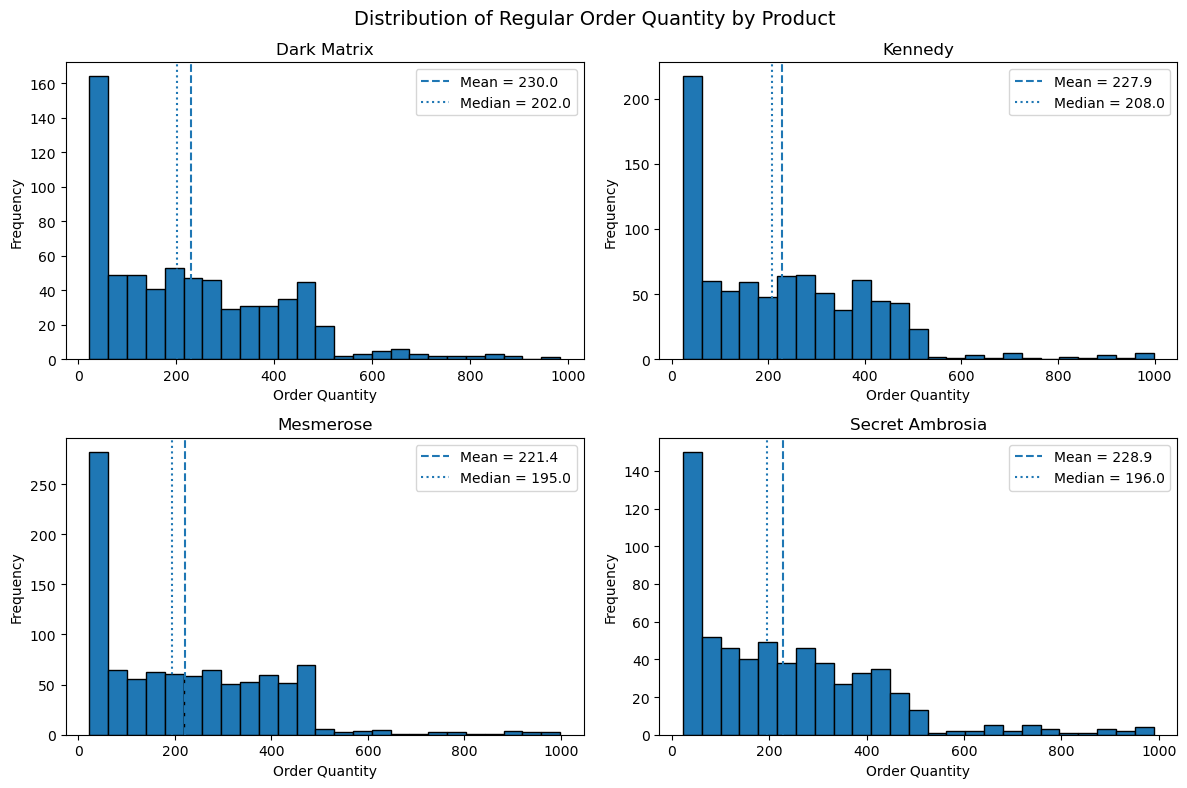

In [9]:
products = sorted(df_full["Product Name"].unique())

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, product in zip(axes.flatten(), products):
    product_data = df_full.loc[
        df_full["Product Name"] == product,
        "Quantity"
    ]
    
    ax.hist(product_data, bins=25, edgecolor="black")
    ax.axvline(product_data.mean(), linestyle="--", linewidth=1.5,
               label=f"Mean = {product_data.mean():.1f}")
    ax.axvline(product_data.median(), linestyle=":", linewidth=1.5,
               label=f"Median = {product_data.median():.1f}")
    
    ax.set_title(product)
    ax.set_xlabel("Order Quantity")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.suptitle("Distribution of Regular Order Quantity by Product", fontsize=14)
plt.tight_layout()
plt.show()

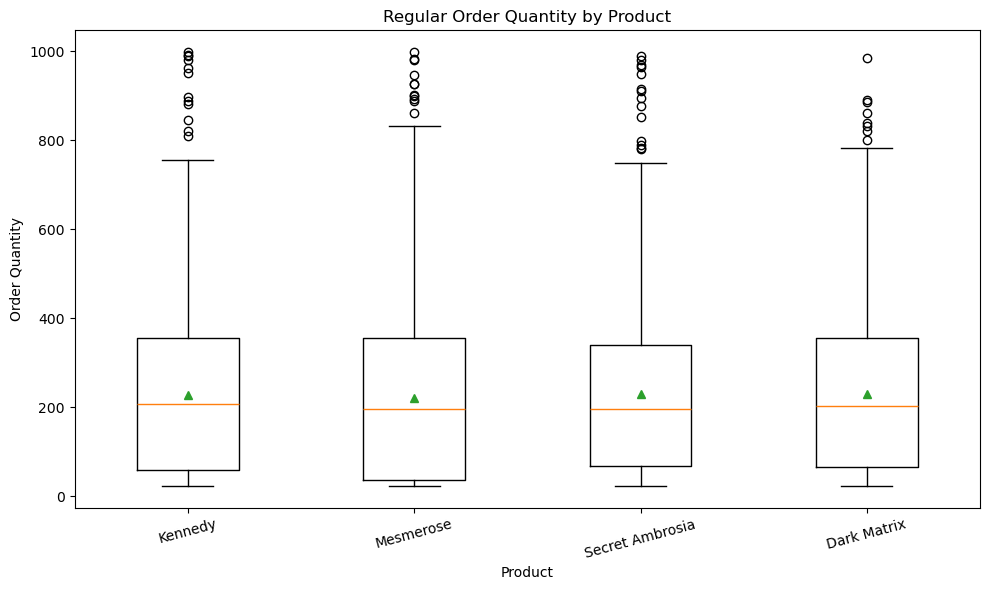

In [10]:
product_order = [
    "Kennedy",
    "Mesmerose",
    "Secret Ambrosia",
    "Dark Matrix"
]

boxplot_data = [
    df_full.loc[
        df_full["Product Name"] == product,
        "Quantity"
    ].values
    for product in product_order
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    boxplot_data,
    tick_labels=product_order,
    showmeans=True
)

plt.title("Regular Order Quantity by Product")
plt.xlabel("Product")
plt.ylabel("Order Quantity")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

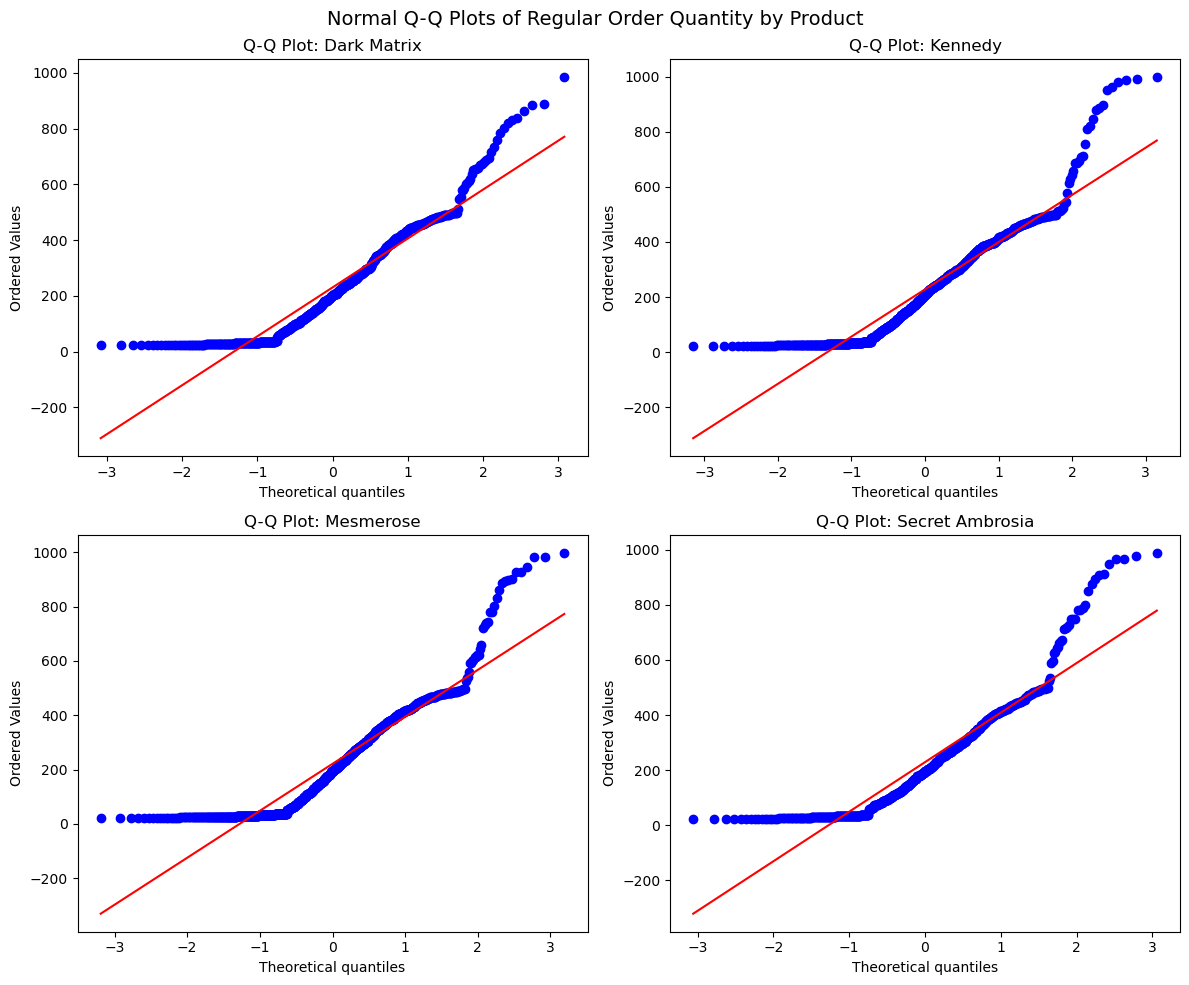

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, product in zip(axes.flatten(), products):
    product_data = df_full.loc[
        df_full["Product Name"] == product,
        "Quantity"
    ]
    
    stats.probplot(product_data, dist="norm", plot=ax)
    ax.set_title(f"Q-Q Plot: {product}")

plt.suptitle(
    "Normal Q-Q Plots of Regular Order Quantity by Product",
    fontsize=14
)

plt.tight_layout()
plt.show()

### 4.2 Homogeneity of Variance Assessment

The homogeneity of variance assumption is assessed before selecting between ordinary one-way ANOVA and Welch ANOVA.

Because Regular Order Quantity is right-skewed and contains genuine high-volume observations, the median-centred Levene test (Brown-Forsythe approach) is used. This version is more robust to departures from normality than a mean-centred variance test.

The hypotheses are:

- **H₀:** The population variance of Quantity is equal across the four perfume products.
- **H₁:** At least one product has a different population variance.

The significance level is $\alpha = 0.05$.

The formal test result is considered together with the observed group standard deviations and variance ratios rather than being interpreted in isolation.


In [12]:
product_groups = [
    df_full.loc[
        df_full["Product Name"] == product,
        "Quantity"
    ].values
    for product in product_order
]

bf_stat, bf_p = stats.levene(
    *product_groups,
    center="median"
)

# Variance comparison
product_variances = (
    df_full.groupby("Product Name")["Quantity"].var()
)

largest_variance = product_variances.max()
smallest_variance = product_variances.min()
variance_ratio = largest_variance / smallest_variance

print("--- BROWN-FORSYTHE TEST: PRODUCT VARIANCES ---")
print(f"Test statistic: {bf_stat:.4f}")
print(f"p-value: {bf_p:.6f}")

print("\n--- PRODUCT VARIANCES ---")
print(product_variances)

print("\n--- VARIANCE COMPARISON ---")
print(f"Largest variance: {largest_variance:,.4f}")
print(f"Smallest variance: {smallest_variance:,.4f}")
print(f"Largest / smallest variance ratio: {variance_ratio:.4f}")

print("\n--- DECISION AT alpha = 0.05 ---")

if bf_p < 0.05:
    print("Reject H0: evidence suggests that product variances are not equal.")
else:
    print("Fail to reject H0: insufficient evidence of unequal product variances.")

--- BROWN-FORSYTHE TEST: PRODUCT VARIANCES ---
Test statistic: 0.1349
p-value: 0.939264

--- PRODUCT VARIANCES ---
Product Name
Dark Matrix       33,689.1919
Kennedy           32,501.3567
Mesmerose         33,440.1275
Secret Ambrosia   36,426.7359
Name: Quantity, dtype: float64

--- VARIANCE COMPARISON ---
Largest variance: 36,426.7359
Smallest variance: 32,501.3567
Largest / smallest variance ratio: 1.1208

--- DECISION AT alpha = 0.05 ---
Fail to reject H0: insufficient evidence of unequal product variances.


## 5. Product Mean Quantity Inference

### 5.1 Business Question

Does the mean Regular Order Quantity differ among the four Fragceylon perfume products: Kennedy, Mesmerose, Secret Ambrosia, and Dark Matrix?

### Hypotheses

**Null hypothesis ($H_0$):**

The population mean Regular Order Quantity is equal across all four perfume products.

\[
\mu_{\text{Kennedy}}
=
\mu_{\text{Mesmerose}}
=
\mu_{\text{Secret Ambrosia}}
=
\mu_{\text{Dark Matrix}}
\]

**Alternative hypothesis ($H_1$):**

At least one perfume product has a different population mean Regular Order Quantity.

### Selected Statistical Test

A **one-way ANOVA** is used to compare mean Regular Order Quantity across the four independent product groups.

### Justification

The response variable, `Quantity`, is quantitative and the explanatory variable, `Product Name`, contains four groups. Although the Quantity distributions are positively skewed and show tail departures from normality, all four product groups have relatively large sample sizes.

The Brown-Forsythe variance test produced no evidence of unequal variances, and the observed product variances were also very similar. Therefore, ordinary one-way ANOVA is considered sufficiently robust and appropriate for the primary comparison.

### Assumption Considerations

- The response variable is quantitative.
- The four product groups are mutually exclusive at the transaction level.
- Variances are sufficiently homogeneous based on the Brown-Forsythe assessment.
- Product distributions are not perfectly normal, but the large group sizes provide substantial robustness to moderate non-normality.
- Order records are treated as observational units. Repeated transactions from the same buyers may introduce some within-buyer dependence, so this limitation must be considered when interpreting the results.

The significance level is $\alpha = 0.05$.

In [13]:
# ---------------------------------------------------------
# One-way ANOVA: Quantity by Product
# ---------------------------------------------------------

anova_stat, anova_p = stats.f_oneway(
    *product_groups
)

# Degrees of freedom
k = len(product_groups)
N = sum(len(group) for group in product_groups)

df_between = k - 1
df_within = N - k

print("--- ONE-WAY ANOVA: QUANTITY BY PRODUCT ---")
print(f"F statistic: {anova_stat:.4f}")
print(f"Degrees of freedom: ({df_between}, {df_within})")
print(f"p-value: {anova_p:.6f}")

print("\n--- DECISION AT alpha = 0.05 ---")

if anova_p < 0.05:
    print("Reject H0.")
    print("There is statistical evidence that at least one product mean differs.")
else:
    print("Fail to reject H0.")
    print("There is insufficient statistical evidence that mean Quantity differs among the four products.")

--- ONE-WAY ANOVA: QUANTITY BY PRODUCT ---
F statistic: 0.3821
Degrees of freedom: (3, 3112)
p-value: 0.765907

--- DECISION AT alpha = 0.05 ---
Fail to reject H0.
There is insufficient statistical evidence that mean Quantity differs among the four products.


### 5.2 Effect Size and Confidence Intervals

Statistical significance alone does not indicate the practical importance of product differences. Therefore, effect sizes are calculated for the overall ANOVA.

- **Eta-squared ($\eta^2$)** estimates the proportion of total variation in Quantity associated with product grouping.
- **Omega-squared ($\omega^2$)** provides a less biased estimate of the corresponding population effect.

In addition, a 95% confidence interval is calculated for the mean Regular Order Quantity of each perfume. These intervals provide information about the uncertainty surrounding the estimated product means.

Because the omnibus ANOVA is not statistically significant, no post-hoc pairwise comparison is performed.

In [14]:
# ---------------------------------------------------------
# ANOVA effect sizes: eta-squared and omega-squared
# ---------------------------------------------------------

grand_mean = df_full["Quantity"].mean()

# Between-group sum of squares
ss_between = sum(
    len(group) * (np.mean(group) - grand_mean) ** 2
    for group in product_groups
)

# Within-group sum of squares
ss_within = sum(
    np.sum((group - np.mean(group)) ** 2)
    for group in product_groups
)

ss_total = ss_between + ss_within

# Mean square within
ms_within = ss_within / df_within

# Eta-squared
eta_squared = ss_between / ss_total

# Omega-squared
omega_squared_raw = (
    ss_between - (df_between * ms_within)
) / (
    ss_total + ms_within
)

# Negative omega-squared estimates are conventionally
# interpreted as approximately zero population effect
omega_squared = max(0, omega_squared_raw)

print("--- ANOVA EFFECT SIZE ---")
print(f"SS Between: {ss_between:,.4f}")
print(f"SS Within:  {ss_within:,.4f}")
print(f"SS Total:   {ss_total:,.4f}")

print(f"\nEta-squared (η²): {eta_squared:.6f}")
print(f"Raw omega-squared (ω²): {omega_squared_raw:.6f}")
print(f"Adjusted omega-squared for interpretation: {omega_squared:.6f}")

--- ANOVA EFFECT SIZE ---
SS Between: 38,782.3021
SS Within:  105,283,056.2820
SS Total:   105,321,838.5841

Eta-squared (η²): 0.000368
Raw omega-squared (ω²): -0.000595
Adjusted omega-squared for interpretation: 0.000000


In [15]:
# ---------------------------------------------------------
# 95% confidence intervals for product means
# ---------------------------------------------------------

product_ci_results = []

for product in product_order:
    
    values = df_full.loc[
        df_full["Product Name"] == product,
        "Quantity"
    ]
    
    n = len(values)
    mean = values.mean()
    sd = values.std(ddof=1)
    se = sd / np.sqrt(n)
    
    t_critical = stats.t.ppf(
        0.975,
        df=n - 1
    )
    
    margin_error = t_critical * se
    
    ci_lower = mean - margin_error
    ci_upper = mean + margin_error
    
    product_ci_results.append({
        "Product": product,
        "n": n,
        "Mean": mean,
        "Std_Dev": sd,
        "SE": se,
        "CI_95_Lower": ci_lower,
        "CI_95_Upper": ci_upper
    })

product_ci = pd.DataFrame(product_ci_results)

print("--- 95% CONFIDENCE INTERVALS FOR PRODUCT MEANS ---")
print(
    product_ci.to_string(
        index=False,
        formatters={
            "Mean": "{:.2f}".format,
            "Std_Dev": "{:.2f}".format,
            "SE": "{:.2f}".format,
            "CI_95_Lower": "{:.2f}".format,
            "CI_95_Upper": "{:.2f}".format
        }
    )
)

--- 95% CONFIDENCE INTERVALS FOR PRODUCT MEANS ---
        Product   n   Mean Std_Dev   SE CI_95_Lower CI_95_Upper
        Kennedy 851 227.89  180.28 6.18      215.76      240.02
      Mesmerose 975 221.40  182.87 5.86      209.91      232.89
Secret Ambrosia 620 228.86  190.86 7.67      213.81      243.91
    Dark Matrix 670 230.03  183.55 7.09      216.11      243.95


### 5.3 Statistical Conclusion and Business Interpretation

The one-way ANOVA found no statistically significant difference in mean Regular Order Quantity among the four perfume products, **F(3, 3112) = 0.3821, p = 0.7659**. Therefore, the null hypothesis was not rejected.

The estimated effect size was extremely small ($\eta^2 = 0.000368$), indicating that product identity accounted for approximately **0.04% of the observed variation in transaction-level order quantity**. The estimated omega-squared was effectively zero, providing further evidence that the practical product effect on average order size was negligible.

The estimated mean quantities and 95% confidence intervals were:

- Kennedy: 227.89 units (95% CI: 215.76 to 240.02)
- Mesmerose: 221.40 units (95% CI: 209.91 to 232.89)
- Secret Ambrosia: 228.86 units (95% CI: 213.81 to 243.91)
- Dark Matrix: 230.03 units (95% CI: 216.11 to 243.95)

From a business perspective, the four perfumes have broadly similar average quantities per Regular Order. Therefore, differences in total product demand are likely to be influenced more strongly by differences in order frequency than by differences in average transaction size.

No post-hoc pairwise comparisons were performed because the overall ANOVA was not statistically significant.

This analysis treats transaction records as observational units. Repeated transactions from the same buyers may introduce within-buyer dependence, and the result should therefore be interpreted as an association within the observed sales data rather than as a causal product effect.

## 6. Product Demand Variability Inference

### Business Question

Does the variability of Regular Order Quantity differ among the four perfume products?

Differences in demand variability are important for inventory management because products with more variable order quantities may require greater attention to uncertainty even when their average order quantities are similar.

### Hypotheses

**Null hypothesis ($H_0$):**

The population variance of Regular Order Quantity is equal across the four perfume products.

**Alternative hypothesis ($H_1$):**

At least one perfume product has a different population variance in Regular Order Quantity.

### Selected Statistical Test

The median-centred **Levene test (Brown-Forsythe approach)** is used because the Quantity distributions are right-skewed and contain genuine high-volume observations.

The significance level is $\alpha = 0.05$.

In [16]:
product_variability = (
    df_full
    .groupby("Product Name")["Quantity"]
    .agg(
        Count="count",
        Mean="mean",
        Std_Dev="std",
        Variance="var",
        Median="median",
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75)
    )
)

product_variability["IQR"] = (
    product_variability["Q3"] -
    product_variability["Q1"]
)

print("--- PRODUCT QUANTITY VARIABILITY ---")
print(product_variability)

print("\n--- BROWN-FORSYTHE TEST ---")
print(f"Test statistic: {bf_stat:.4f}")
print(f"Degrees of freedom: ({len(product_groups) - 1}, {len(df_full) - len(product_groups)})")
print(f"p-value: {bf_p:.6f}")

print("\n--- VARIANCE RATIO ---")
print(f"Largest / smallest variance ratio: {variance_ratio:.4f}")

--- PRODUCT QUANTITY VARIABILITY ---
                 Count     Mean  Std_Dev    Variance   Median      Q1  \
Product Name                                                            
Dark Matrix        670 230.0299 183.5462 33,689.1919 202.0000 66.0000   
Kennedy            851 227.8872 180.2813 32,501.3567 208.0000 58.0000   
Mesmerose          975 221.4010 182.8664 33,440.1275 195.0000 37.0000   
Secret Ambrosia    620 228.8581 190.8579 36,426.7359 196.0000 67.5000   

                      Q3      IQR  
Product Name                       
Dark Matrix     356.0000 290.0000  
Kennedy         356.5000 298.5000  
Mesmerose       356.0000 319.0000  
Secret Ambrosia 340.2500 272.7500  

--- BROWN-FORSYTHE TEST ---
Test statistic: 0.1349
Degrees of freedom: (3, 3112)
p-value: 0.939264

--- VARIANCE RATIO ---
Largest / smallest variance ratio: 1.1208


### 6.1 Statistical Conclusion and Business Interpretation

The Brown-Forsythe test found no statistically significant difference in Regular Order Quantity variance among the four perfume products, **F(3, 3112) = 0.1349, p = 0.9393**. Therefore, the null hypothesis of equal product variances was not rejected.

The observed standard deviations were also similar, ranging from approximately 180.28 to 190.86 units, while the largest-to-smallest variance ratio was only 1.1208.

From a business perspective, there is no evidence that one of the four perfumes has substantially greater transaction-level order quantity variability than the others. Combined with the earlier ANOVA result, the perfumes display broadly similar average order quantities and broadly similar variability.

Therefore, differences in total product demand should not be interpreted primarily as differences in typical order size or order-size volatility. Differences in order frequency remain an important contributor to the observed total-demand differences.

## 7. Local vs Japan Market Inference

### 7.1 Controlled Market Comparison

The initial dataset structure showed that Japan transactions occur only within the post-April-2025 Main Dealer structure and are associated with a single buyer.

Further investigation showed that the same buyer also has Local transactions. Therefore, the market analysis is restricted to transactions belonging to this buyer.

This creates a more comparable analytical subset in which:

- buyer identity is held constant;
- sales channel is held constant as Main Dealer;
- sales regime is held constant as Post-April-2025;
- both Local and Japan transactions are represented.

The analysis therefore examines whether transaction-level Regular Order Quantity differs between Local and Japan observations **within this buyer's recorded orders**.

The comparison remains observational and should not be interpreted as evidence that export market itself caused any observed difference. Individual transactions are also treated as analytical observations even though repeated orders from the same buyer may not be perfectly independent.

In [17]:
market_distribution = (
    df_market
    .groupby("Export Market")["Quantity"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Std_Dev="std",
        Variance="var",
        Minimum="min",
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75),
        Maximum="max"
    )
)

market_distribution["IQR"] = (
    market_distribution["Q3"] -
    market_distribution["Q1"]
)

market_distribution["Skewness"] = (
    df_market
    .groupby("Export Market")["Quantity"]
    .apply(lambda x: stats.skew(x, bias=False))
)

print("--- CONTROLLED LOCAL VS JAPAN DISTRIBUTION ---")
print(market_distribution)

--- CONTROLLED LOCAL VS JAPAN DISTRIBUTION ---
               Count     Mean   Median  Std_Dev    Variance  Minimum       Q1  \
Export Market                                                                   
Japan            185 622.5297 623.0000 212.4049 45,115.8266      209 468.0000   
Local            151 283.7020 282.0000 127.7418 16,317.9573       55 169.5000   

                    Q3  Maximum      IQR  Skewness  
Export Market                                       
Japan         783.0000      998 315.0000   -0.0425  
Local         393.5000      499 224.0000   -0.0254  


In [18]:
# ---------------------------------------------------------
# Brown-Forsythe test:
# Local vs Japan within controlled market subset
# ---------------------------------------------------------

local_quantity = df_market.loc[
    df_market["Export Market"] == "Local",
    "Quantity"
].values

japan_quantity = df_market.loc[
    df_market["Export Market"] == "Japan",
    "Quantity"
].values

market_bf_stat, market_bf_p = stats.levene(
    local_quantity,
    japan_quantity,
    center="median"
)

local_var = np.var(local_quantity, ddof=1)
japan_var = np.var(japan_quantity, ddof=1)

market_variance_ratio = max(local_var, japan_var) / min(local_var, japan_var)

print("--- BROWN-FORSYTHE TEST: LOCAL VS JAPAN ---")
print(f"Test statistic: {market_bf_stat:.4f}")
print(f"p-value: {market_bf_p:.6f}")

print("\n--- VARIANCES ---")
print(f"Local variance: {local_var:,.4f}")
print(f"Japan variance: {japan_var:,.4f}")
print(f"Largest / smallest variance ratio: {market_variance_ratio:.4f}")

print("\n--- DECISION AT alpha = 0.05 ---")

if market_bf_p < 0.05:
    print("Reject H0: evidence suggests unequal variances.")
else:
    print("Fail to reject H0: insufficient evidence of unequal variances.")

--- BROWN-FORSYTHE TEST: LOCAL VS JAPAN ---
Test statistic: 35.9835
p-value: 0.000000

--- VARIANCES ---
Local variance: 16,317.9573
Japan variance: 45,115.8266
Largest / smallest variance ratio: 2.7648

--- DECISION AT alpha = 0.05 ---
Reject H0: evidence suggests unequal variances.


### 7.2 Distribution and Variance Assessment

Before comparing mean Quantity between Local and Japan transactions, the distributions are examined graphically.

The descriptive statistics indicate that both groups are approximately symmetric, with means and medians that are very similar within each market. However, the Brown-Forsythe test provides strong evidence that the population variances are unequal.

Therefore, the final mean comparison will use Welch's independent-samples t-test, which does not require equal population variances.

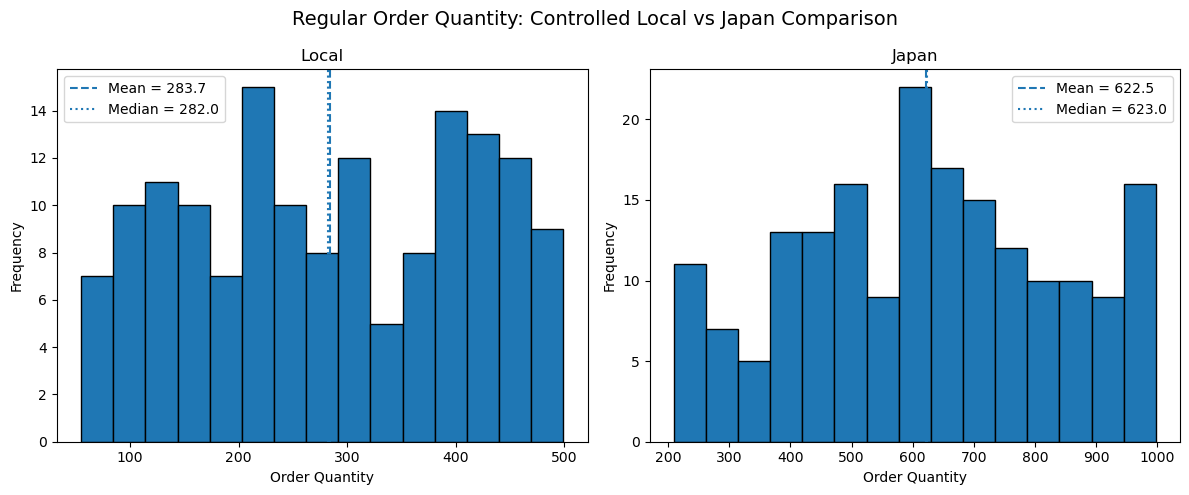

In [19]:
# ---------------------------------------------------------
# Histograms: controlled Local vs Japan comparison
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, market in zip(axes, ["Local", "Japan"]):
    
    values = df_market.loc[
        df_market["Export Market"] == market,
        "Quantity"
    ]
    
    ax.hist(values, bins=15, edgecolor="black")
    ax.axvline(
        values.mean(),
        linestyle="--",
        linewidth=1.5,
        label=f"Mean = {values.mean():.1f}"
    )
    ax.axvline(
        values.median(),
        linestyle=":",
        linewidth=1.5,
        label=f"Median = {values.median():.1f}"
    )
    
    ax.set_title(market)
    ax.set_xlabel("Order Quantity")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.suptitle(
    "Regular Order Quantity: Controlled Local vs Japan Comparison",
    fontsize=14
)

plt.tight_layout()
plt.show()

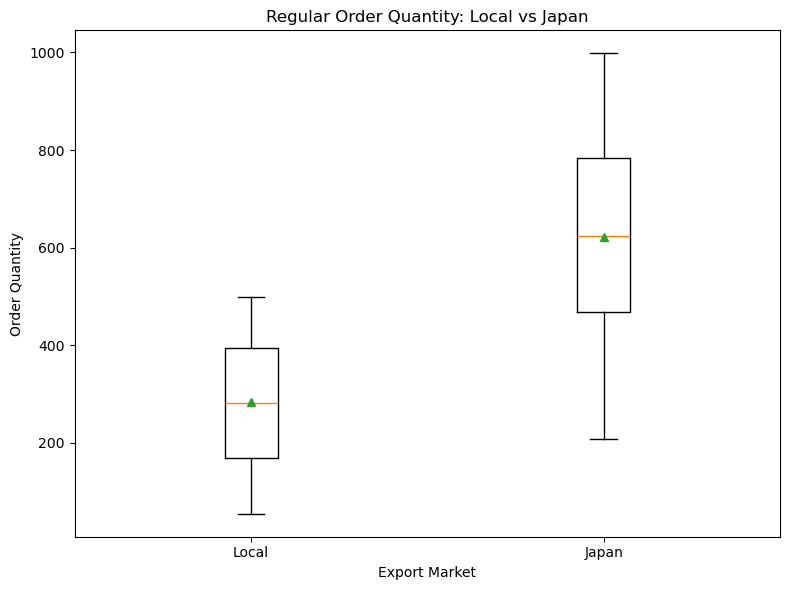

In [20]:
# ---------------------------------------------------------
# Boxplot: controlled Local vs Japan comparison
# ---------------------------------------------------------

market_box_data = [
    local_quantity,
    japan_quantity
]

plt.figure(figsize=(8, 6))

plt.boxplot(
    market_box_data,
    tick_labels=["Local", "Japan"],
    showmeans=True
)

plt.title("Regular Order Quantity: Local vs Japan")
plt.xlabel("Export Market")
plt.ylabel("Order Quantity")

plt.tight_layout()
plt.show()

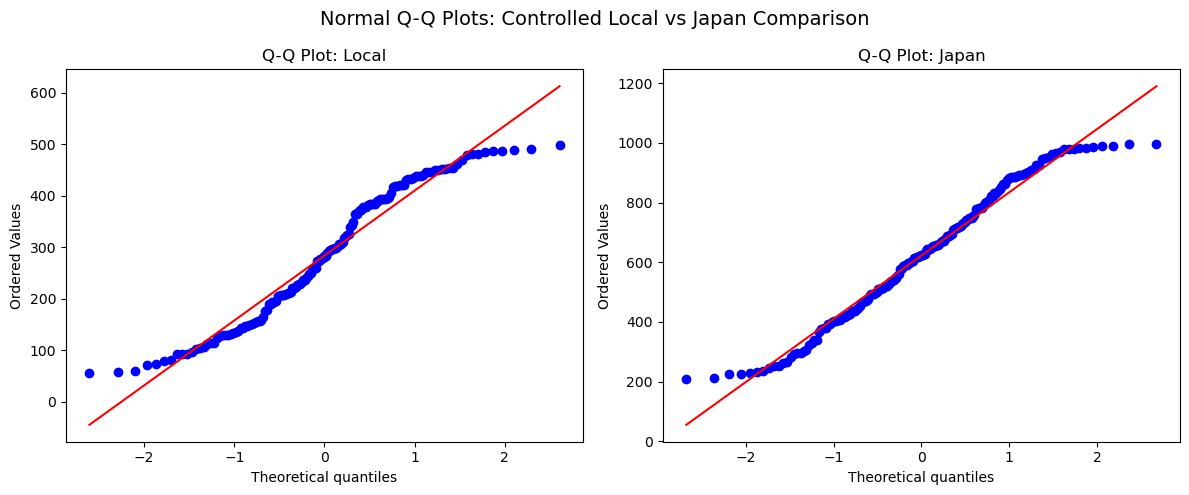

In [21]:
# ---------------------------------------------------------
# Q-Q plots: controlled Local vs Japan comparison
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

stats.probplot(
    local_quantity,
    dist="norm",
    plot=axes[0]
)
axes[0].set_title("Q-Q Plot: Local")

stats.probplot(
    japan_quantity,
    dist="norm",
    plot=axes[1]
)
axes[1].set_title("Q-Q Plot: Japan")

plt.suptitle(
    "Normal Q-Q Plots: Controlled Local vs Japan Comparison",
    fontsize=14
)

plt.tight_layout()
plt.show()

### 7.3 Welch Independent-Samples t-Test

#### Business Question

Within the transactions of the buyer represented in both markets, does mean Regular Order Quantity differ between Local and Japan observations?

#### Hypotheses

**Null hypothesis ($H_0$):**

\[
\mu_{\text{Japan}} = \mu_{\text{Local}}
\]

The population mean Regular Order Quantity is equal between Japan and Local transactions within the controlled buyer/channel/regime subset.

**Alternative hypothesis ($H_1$):**

\[
\mu_{\text{Japan}} \neq \mu_{\text{Local}}
\]

The population mean Regular Order Quantity differs between Japan and Local transactions within this subset.

#### Selected Statistical Test

A **Welch independent-samples t-test** is used.

Welch's test is preferred because the Local and Japan groups have unequal sample sizes and the Brown-Forsythe test showed strong evidence of unequal variances. The graphical assessment showed some departures from perfect normality, but both groups are reasonably large and approximately symmetric.

The comparison is observational. It controls buyer identity, sales channel, and sales regime by restricting the analysis to the same buyer's post-April-2025 Main Dealer transactions. However, repeated transactions from the same buyer may still violate strict independence, and the result should not be interpreted as a causal effect of market.
A paired t-test is not used because individual Local and Japan transactions are not naturally matched one-to-one. The Welch test therefore compares the two sets of transaction quantities as separate samples, while the repeated-buyer independence limitation is acknowledged explicitly.


In [22]:
# ---------------------------------------------------------
# Welch independent-samples t-test:
# Japan vs Local within controlled market subset
# Mean difference defined as Japan - Local
# ---------------------------------------------------------

# Sample statistics
n_local = len(local_quantity)
n_japan = len(japan_quantity)

mean_local = np.mean(local_quantity)
mean_japan = np.mean(japan_quantity)

var_local = np.var(local_quantity, ddof=1)
var_japan = np.var(japan_quantity, ddof=1)

sd_local = np.sqrt(var_local)
sd_japan = np.sqrt(var_japan)

# Welch t-test
welch_t, welch_p = stats.ttest_ind(
    japan_quantity,
    local_quantity,
    equal_var=False
)

# Mean difference: Japan - Local
mean_difference = mean_japan - mean_local

# Standard error for Welch difference
se_difference = np.sqrt(
    (var_japan / n_japan) +
    (var_local / n_local)
)

# Welch-Satterthwaite degrees of freedom
welch_df = (
    (var_japan / n_japan + var_local / n_local) ** 2
) / (
    ((var_japan / n_japan) ** 2 / (n_japan - 1)) +
    ((var_local / n_local) ** 2 / (n_local - 1))
)

# 95% confidence interval for Japan - Local mean difference
t_critical = stats.t.ppf(
    0.975,
    df=welch_df
)

ci_lower = mean_difference - (t_critical * se_difference)
ci_upper = mean_difference + (t_critical * se_difference)

print("--- WELCH t-TEST: CONTROLLED LOCAL VS JAPAN ---")
print(f"Local n: {n_local}")
print(f"Japan n: {n_japan}")

print(f"\nLocal mean: {mean_local:.4f}")
print(f"Japan mean: {mean_japan:.4f}")

print(f"\nMean difference (Japan - Local): {mean_difference:.4f}")

print(f"\nWelch t statistic: {welch_t:.4f}")
print(f"Welch degrees of freedom: {welch_df:.4f}")
print(f"p-value: {welch_p:.10g}")

print("\n95% CI for mean difference (Japan - Local):")
print(f"[{ci_lower:.4f}, {ci_upper:.4f}]")

print("\n--- DECISION AT alpha = 0.05 ---")

if welch_p < 0.05:
    print("Reject H0.")
    print("There is statistical evidence that mean Quantity differs between Japan and Local transactions in this controlled subset.")
else:
    print("Fail to reject H0.")
    print("There is insufficient statistical evidence that mean Quantity differs between Japan and Local transactions in this controlled subset.")

--- WELCH t-TEST: CONTROLLED LOCAL VS JAPAN ---
Local n: 151
Japan n: 185

Local mean: 283.7020
Japan mean: 622.5297

Mean difference (Japan - Local): 338.8277

Welch t statistic: 18.0612
Welch degrees of freedom: 308.8171
p-value: 2.859744711e-50

95% CI for mean difference (Japan - Local):
[301.9143, 375.7412]

--- DECISION AT alpha = 0.05 ---
Reject H0.
There is statistical evidence that mean Quantity differs between Japan and Local transactions in this controlled subset.


### 7.4 Effect Size

In addition to statistical significance, the magnitude of the observed market difference is assessed.

The raw mean difference in units is the primary business effect measure because it is directly interpretable for Fragceylon. A standardized effect size, **Hedges' g**, is also calculated to express the difference relative to the observed within-group variability.

Because the two groups have unequal variances, the standardized effect size should be interpreted cautiously and together with the raw mean difference and its 95% confidence interval.

In [23]:
# ---------------------------------------------------------
# Hedges' g:
# Controlled Japan vs Local comparison
# ---------------------------------------------------------

# Pooled standard deviation for standardized effect size
pooled_sd = np.sqrt(
    (
        (n_japan - 1) * var_japan +
        (n_local - 1) * var_local
    )
    /
    (n_japan + n_local - 2)
)

# Cohen's d
cohens_d = mean_difference / pooled_sd

# Small-sample correction
effect_df = n_japan + n_local - 2

J = 1 - (
    3 /
    (4 * effect_df - 1)
)

# Hedges' g
hedges_g = J * cohens_d

print("--- EFFECT SIZE: CONTROLLED LOCAL VS JAPAN ---")
print(f"Pooled SD: {pooled_sd:.4f}")
print(f"Cohen's d: {cohens_d:.4f}")
print(f"Hedges' g: {hedges_g:.4f}")

print("\n--- RAW BUSINESS EFFECT ---")
print(f"Mean difference (Japan - Local): {mean_difference:.4f} units")
print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}] units")

--- EFFECT SIZE: CONTROLLED LOCAL VS JAPAN ---
Pooled SD: 179.3952
Cohen's d: 1.8887
Hedges' g: 1.8845

--- RAW BUSINESS EFFECT ---
Mean difference (Japan - Local): 338.8277 units
95% CI: [301.9143, 375.7412] units


### 7.5 Sensitivity Analysis for Genuine High-Volume Orders

The primary market analysis retains all valid transactions, including the 41 genuine high-volume orders identified during Task 3.

Because all 41 flagged high-volume observations occur within the Japan group, a supplementary sensitivity analysis is performed to assess how strongly these observations influence the observed Local-Japan difference.

This analysis does **not** treat the flagged transactions as errors and does not replace the primary result. Its purpose is only to evaluate the robustness of the statistical conclusion when exceptionally large valid orders are temporarily excluded.

In [24]:
# ---------------------------------------------------------
# Sensitivity analysis:
# Controlled Local vs Japan comparison excluding
# the 41 IQR-flagged high-volume orders
# ---------------------------------------------------------

df_market_sensitivity = df_market[
    df_market["Outlier_IQR_Flag"] == "No"
].copy()

local_sens = df_market_sensitivity.loc[
    df_market_sensitivity["Export Market"] == "Local",
    "Quantity"
].values

japan_sens = df_market_sensitivity.loc[
    df_market_sensitivity["Export Market"] == "Japan",
    "Quantity"
].values

# Sample statistics
n_local_sens = len(local_sens)
n_japan_sens = len(japan_sens)

mean_local_sens = np.mean(local_sens)
mean_japan_sens = np.mean(japan_sens)

var_local_sens = np.var(local_sens, ddof=1)
var_japan_sens = np.var(japan_sens, ddof=1)

sd_local_sens = np.sqrt(var_local_sens)
sd_japan_sens = np.sqrt(var_japan_sens)

mean_diff_sens = mean_japan_sens - mean_local_sens

# Brown-Forsythe test
sens_bf_stat, sens_bf_p = stats.levene(
    local_sens,
    japan_sens,
    center="median"
)

# Welch t-test
sens_t, sens_p = stats.ttest_ind(
    japan_sens,
    local_sens,
    equal_var=False
)

# Standard error
sens_se = np.sqrt(
    (var_japan_sens / n_japan_sens) +
    (var_local_sens / n_local_sens)
)

# Welch-Satterthwaite degrees of freedom
sens_df = (
    (var_japan_sens / n_japan_sens + var_local_sens / n_local_sens) ** 2
) / (
    ((var_japan_sens / n_japan_sens) ** 2 / (n_japan_sens - 1)) +
    ((var_local_sens / n_local_sens) ** 2 / (n_local_sens - 1))
)

# 95% CI
sens_t_critical = stats.t.ppf(
    0.975,
    df=sens_df
)

sens_ci_lower = mean_diff_sens - sens_t_critical * sens_se
sens_ci_upper = mean_diff_sens + sens_t_critical * sens_se

# Hedges' g
sens_pooled_sd = np.sqrt(
    (
        (n_japan_sens - 1) * var_japan_sens +
        (n_local_sens - 1) * var_local_sens
    )
    /
    (n_japan_sens + n_local_sens - 2)
)

sens_d = mean_diff_sens / sens_pooled_sd

sens_effect_df = n_japan_sens + n_local_sens - 2

sens_J = 1 - (
    3 / (4 * sens_effect_df - 1)
)

sens_g = sens_J * sens_d

print("--- SENSITIVITY ANALYSIS: HIGH-VOLUME ORDERS EXCLUDED ---")

print(f"Local n: {n_local_sens}")
print(f"Japan n: {n_japan_sens}")

print(f"\nLocal mean: {mean_local_sens:.4f}")
print(f"Japan mean: {mean_japan_sens:.4f}")
print(f"Mean difference (Japan - Local): {mean_diff_sens:.4f}")

print("\n--- VARIANCE CHECK ---")
print(f"Brown-Forsythe statistic: {sens_bf_stat:.4f}")
print(f"Brown-Forsythe p-value: {sens_bf_p:.6f}")

print("\n--- WELCH t-TEST ---")
print(f"t statistic: {sens_t:.4f}")
print(f"Degrees of freedom: {sens_df:.4f}")
print(f"p-value: {sens_p:.10g}")

print("\n95% CI for mean difference:")
print(f"[{sens_ci_lower:.4f}, {sens_ci_upper:.4f}]")

print("\n--- EFFECT SIZE ---")
print(f"Hedges' g: {sens_g:.4f}")

--- SENSITIVITY ANALYSIS: HIGH-VOLUME ORDERS EXCLUDED ---
Local n: 151
Japan n: 144

Local mean: 283.7020
Japan mean: 539.6736
Mean difference (Japan - Local): 255.9716

--- VARIANCE CHECK ---
Brown-Forsythe statistic: 7.4215
Brown-Forsythe p-value: 0.006832

--- WELCH t-TEST ---
t statistic: 15.0819
Degrees of freedom: 272.5880
p-value: 8.676108243e-38

95% CI for mean difference:
[222.5586, 289.3847]

--- EFFECT SIZE ---
Hedges' g: 1.7617


In [25]:
comparison_table = pd.DataFrame({
    "Analysis": [
        "Primary - All Valid Orders",
        "Sensitivity - Flagged High Orders Excluded"
    ],
    "Local_n": [
        n_local,
        n_local_sens
    ],
    "Japan_n": [
        n_japan,
        n_japan_sens
    ],
    "Local_Mean": [
        mean_local,
        mean_local_sens
    ],
    "Japan_Mean": [
        mean_japan,
        mean_japan_sens
    ],
    "Mean_Difference_Japan_minus_Local": [
        mean_difference,
        mean_diff_sens
    ],
    "CI_Lower": [
        ci_lower,
        sens_ci_lower
    ],
    "CI_Upper": [
        ci_upper,
        sens_ci_upper
    ],
    "Hedges_g": [
        hedges_g,
        sens_g
    ]
})

print("--- PRIMARY VS SENSITIVITY COMPARISON ---")
print(
    comparison_table.to_string(
        index=False,
        formatters={
            "Local_Mean": "{:.2f}".format,
            "Japan_Mean": "{:.2f}".format,
            "Mean_Difference_Japan_minus_Local": "{:.2f}".format,
            "CI_Lower": "{:.2f}".format,
            "CI_Upper": "{:.2f}".format,
            "Hedges_g": "{:.3f}".format
        }
    )
)

--- PRIMARY VS SENSITIVITY COMPARISON ---
                                  Analysis  Local_n  Japan_n Local_Mean Japan_Mean Mean_Difference_Japan_minus_Local CI_Lower CI_Upper Hedges_g
                Primary - All Valid Orders      151      185     283.70     622.53                            338.83   301.91   375.74    1.884
Sensitivity - Flagged High Orders Excluded      151      144     283.70     539.67                            255.97   222.56   289.38    1.762


### 7.6 Sensitivity Analysis Interpretation

The primary Local-Japan comparison retained all valid transactions, including the 41 genuine high-volume Japan orders. To assess whether these observations were driving the result, the comparison was repeated after temporarily excluding the IQR-flagged high-volume transactions.

In the primary analysis, mean Quantity was 622.53 units for Japan transactions and 283.70 units for Local transactions, producing a mean difference of 338.83 units.

After temporarily excluding the 41 flagged high-volume Japan transactions, the Japan mean decreased to 539.67 units. Nevertheless, the remaining mean difference was still substantial at 255.97 units (95% CI: 222.56 to 289.38).

The sensitivity Welch t-test remained statistically significant, **t(272.59) = 15.0819, p < 0.001**, and the standardized effect remained large (**Hedges' g = 1.7617**).

Therefore, the exceptionally large Japan orders contribute to the magnitude of the observed difference but do not fully explain it. The Local-Japan association remains strong after their temporary exclusion.

The complete-data analysis remains the primary result because the 41 high-volume transactions are valid commercial orders rather than data errors.

### 7.7 Temporal Structure of the Controlled Market Comparison

Although the controlled market subset holds buyer identity, sales channel, and sales regime constant, Local and Japan transactions may still occur during different portions of the study period.

The transaction dates and monthly representation are therefore examined to determine whether there is sufficient temporal overlap between the two market groups. Any remaining imbalance in timing must be considered as a potential confounding factor when interpreting the Local-Japan association.

In [26]:
# ---------------------------------------------------------
# Temporal structure:
# Controlled Local vs Japan comparison
# ---------------------------------------------------------

print("--- DATE RANGE BY MARKET ---")

market_dates = (
    df_market
    .groupby("Export Market")["Date"]
    .agg(
        First_Date="min",
        Last_Date="max",
        Unique_Dates="nunique",
        Number_of_Orders="count"
    )
)

print(market_dates)

print("\n--- ORDERS BY YEAR-MONTH AND MARKET ---")

market_month_counts = pd.crosstab(
    df_market["Year_Month"],
    df_market["Export Market"]
)

print(market_month_counts)

print("\n--- MONTHS REPRESENTED BY MARKET ---")

for market in ["Local", "Japan"]:
    represented_months = (
        df_market.loc[
            df_market["Export Market"] == market,
            "Year_Month"
        ]
        .drop_duplicates()
        .sort_values()
    )
    
    print(f"\n{market}: {len(represented_months)} Year-Month periods")
    print(represented_months.to_list())

--- DATE RANGE BY MARKET ---
              First_Date  Last_Date  Unique_Dates  Number_of_Orders
Export Market                                                      
Japan         2025-04-01 2026-06-30           130               185
Local         2025-04-01 2026-06-12           115               151

--- ORDERS BY YEAR-MONTH AND MARKET ---
Export Market  Japan  Local
Year_Month                 
2025-04           36     23
2025-05            5      2
2025-06            3      1
2025-07            1      1
2025-08            1      5
2025-09            1      4
2025-10            3      5
2025-11           11     10
2025-12           32     26
2026-01           30     29
2026-02            4      3
2026-03           17     14
2026-04           33     25
2026-05            4      0
2026-06            4      3

--- MONTHS REPRESENTED BY MARKET ---

Local: 14 Year-Month periods
['2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01', '20

### 7.8 Statistical Conclusion and Business Interpretation

Within the controlled subset of transactions belonging to the same buyer, Main Dealer channel, and post-April-2025 sales regime, mean Regular Order Quantity differed substantially between Local and Japan observations.

Japan transactions had a mean Quantity of 622.53 units, compared with 283.70 units for Local transactions. The estimated mean difference was **338.83 units** in favour of Japan-labelled transactions.

Welch's independent-samples t-test showed that this difference was statistically significant, **t(308.82) = 18.0612, p < 0.001**. The 95% confidence interval for the Japan-minus-Local mean difference was **301.91 to 375.74 units**.

The standardized effect was also large (**Hedges' g = 1.8845**), indicating a substantial observed separation between the two transaction groups. Because the group variances were unequal, the raw mean difference and its confidence interval are emphasized as the primary business effect measures.

A sensitivity analysis excluding the 41 genuine high-volume Japan orders reduced the mean difference from 338.83 to 255.97 units. However, the difference remained statistically significant, **t(272.59) = 15.0819, p < 0.001**, with a 95% confidence interval of **222.56 to 289.38 units** and a large effect size (**Hedges' g = 1.7617**). Therefore, the high-volume transactions increase the magnitude of the observed difference but do not fully explain it.

The Local and Japan transactions also showed substantial temporal overlap. Both markets were represented across nearly the entire post-April-2025 period, with Local transactions appearing in 14 of the 15 Year-Month periods represented by Japan.

From a business perspective, this buyer's Japan-labelled transactions were associated with substantially larger order quantities than the same buyer's Local transactions during the same general business regime. This may be relevant for market-specific demand planning and large-order preparation.

However, the result must not be interpreted as evidence that the Japan market itself caused larger order quantities. The analysis is based on repeated transactions from one buyer, and individual orders may not be fully independent. Although buyer identity, channel, regime, and much of the time period were controlled through restriction, other unobserved transaction-level factors may still contribute to the observed difference.

## 8. Channel Quantity Inference

### 8.1 Pre-April-2025 Shop vs Small Dealer Comparison

A direct comparison involving Main Dealer would be strongly confounded with the April 2025 structural business change because Main Dealer transactions occur only in the post-April-2025 regime.

Therefore, the formal channel comparison is restricted to the pre-April-2025 period, during which both Shop and Small Dealer transactions were recorded.

The business question is:

**Within the pre-April-2025 sales regime, does mean Regular Order Quantity differ between Shop and Small Dealer transactions?**

Before hypothesis testing, buyer representation and the Quantity distributions are examined to identify any remaining structural differences between the two channel groups.

In [27]:
# ---------------------------------------------------------
# Buyer structure:
# Pre-April Shop vs Small Dealer comparison
# ---------------------------------------------------------

print("--- BUYERS BY CHANNEL ---")

channel_buyers = (
    df_channel_pre
    .groupby("Channel Type")["Buyer"]
    .agg(
        Unique_Buyers="nunique",
        Number_of_Orders="count"
    )
)

print(channel_buyers)

shop_buyers = set(
    df_channel_pre.loc[
        df_channel_pre["Channel Type"] == "Shop",
        "Buyer"
    ].unique()
)

small_dealer_buyers = set(
    df_channel_pre.loc[
        df_channel_pre["Channel Type"] == "Small Dealer",
        "Buyer"
    ].unique()
)

common_buyers = shop_buyers.intersection(small_dealer_buyers)

print("\n--- BUYER OVERLAP ---")
print(f"Unique Shop buyers: {len(shop_buyers)}")
print(f"Unique Small Dealer buyers: {len(small_dealer_buyers)}")
print(f"Buyers appearing in both channels: {len(common_buyers)}")

print("\nCommon buyers:")
print(sorted(common_buyers))

--- BUYERS BY CHANNEL ---
              Unique_Buyers  Number_of_Orders
Channel Type                                 
Shop                     35               751
Small Dealer              8               351

--- BUYER OVERLAP ---
Unique Shop buyers: 35
Unique Small Dealer buyers: 8
Buyers appearing in both channels: 0

Common buyers:
[]


In [28]:
# ---------------------------------------------------------
# Numerical distribution assessment:
# Pre-April Shop vs Small Dealer
# ---------------------------------------------------------

channel_distribution = (
    df_channel_pre
    .groupby("Channel Type")["Quantity"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Std_Dev="std",
        Variance="var",
        Minimum="min",
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75),
        Maximum="max"
    )
)

channel_distribution["IQR"] = (
    channel_distribution["Q3"] -
    channel_distribution["Q1"]
)

channel_distribution["Skewness"] = (
    df_channel_pre
    .groupby("Channel Type")["Quantity"]
    .apply(lambda x: stats.skew(x, bias=False))
)

print("--- PRE-APRIL CHANNEL DISTRIBUTION ---")
print(channel_distribution)

--- PRE-APRIL CHANNEL DISTRIBUTION ---
              Count     Mean   Median  Std_Dev   Variance  Minimum       Q1  \
Channel Type                                                                  
Shop            751  29.8921  30.0000   4.2627    18.1710       23  26.0000   
Small Dealer    351 173.1225 179.0000  72.3818 5,239.1249       51 103.0000   

                   Q3  Maximum      IQR  Skewness  
Channel Type                                       
Shop          34.0000       37   8.0000    0.0088  
Small Dealer 234.5000      299 131.5000    0.0365  


In [29]:
# ---------------------------------------------------------
# Brown-Forsythe test:
# Shop vs Small Dealer
# ---------------------------------------------------------

shop_quantity = df_channel_pre.loc[
    df_channel_pre["Channel Type"] == "Shop",
    "Quantity"
].values

small_dealer_quantity = df_channel_pre.loc[
    df_channel_pre["Channel Type"] == "Small Dealer",
    "Quantity"
].values

channel_bf_stat, channel_bf_p = stats.levene(
    shop_quantity,
    small_dealer_quantity,
    center="median"
)

shop_var = np.var(shop_quantity, ddof=1)
small_dealer_var = np.var(small_dealer_quantity, ddof=1)

channel_variance_ratio = (
    max(shop_var, small_dealer_var) /
    min(shop_var, small_dealer_var)
)

print("--- BROWN-FORSYTHE TEST: SHOP VS SMALL DEALER ---")
print(f"Test statistic: {channel_bf_stat:.4f}")
print(f"p-value: {channel_bf_p:.6f}")

print("\n--- VARIANCES ---")
print(f"Shop variance: {shop_var:,.4f}")
print(f"Small Dealer variance: {small_dealer_var:,.4f}")
print(f"Largest / smallest variance ratio: {channel_variance_ratio:.4f}")

print("\n--- DECISION AT alpha = 0.05 ---")

if channel_bf_p < 0.05:
    print("Reject H0: evidence suggests unequal variances.")
else:
    print("Fail to reject H0: insufficient evidence of unequal variances.")

--- BROWN-FORSYTHE TEST: SHOP VS SMALL DEALER ---
Test statistic: 2014.6245
p-value: 0.000000

--- VARIANCES ---
Shop variance: 18.1710
Small Dealer variance: 5,239.1249
Largest / smallest variance ratio: 288.3231

--- DECISION AT alpha = 0.05 ---
Reject H0: evidence suggests unequal variances.


### 8.2 Welch Independent-Samples t-Test

#### Business Question

Within the pre-April-2025 sales regime, does mean Regular Order Quantity differ between Shop and Small Dealer transactions?

#### Hypotheses

**Null hypothesis ($H_0$):**

\[
\mu_{\text{Small Dealer}} = \mu_{\text{Shop}}
\]

**Alternative hypothesis ($H_1$):**

\[
\mu_{\text{Small Dealer}} \neq \mu_{\text{Shop}}
\]

#### Selected Statistical Test

A **Welch independent-samples t-test** is used because the two channel groups have substantially unequal variances and unequal sample sizes.

The Quantity distributions themselves are approximately symmetric, but the Brown-Forsythe test showed strong evidence of variance heterogeneity. Welch's procedure therefore provides a more appropriate comparison of the group means than the equal-variance Student t-test.

An important limitation is that the Shop and Small Dealer groups contain completely different buyers. Therefore, the comparison describes an observed difference between the recorded channel structures and their associated buyer groups; it does not isolate a causal effect of sales channel.

In [30]:
# ---------------------------------------------------------
# Welch independent-samples t-test:
# Small Dealer vs Shop
# Mean difference defined as Small Dealer - Shop
# ---------------------------------------------------------

# Sample statistics
n_shop = len(shop_quantity)
n_small = len(small_dealer_quantity)

mean_shop = np.mean(shop_quantity)
mean_small = np.mean(small_dealer_quantity)

var_shop = np.var(shop_quantity, ddof=1)
var_small = np.var(small_dealer_quantity, ddof=1)

# Welch t-test
channel_t, channel_p = stats.ttest_ind(
    small_dealer_quantity,
    shop_quantity,
    equal_var=False
)

# Mean difference
channel_mean_diff = mean_small - mean_shop

# Standard error
channel_se = np.sqrt(
    (var_small / n_small) +
    (var_shop / n_shop)
)

# Welch-Satterthwaite degrees of freedom
channel_df = (
    (var_small / n_small + var_shop / n_shop) ** 2
) / (
    ((var_small / n_small) ** 2 / (n_small - 1)) +
    ((var_shop / n_shop) ** 2 / (n_shop - 1))
)

# 95% confidence interval
channel_t_critical = stats.t.ppf(
    0.975,
    df=channel_df
)

channel_ci_lower = (
    channel_mean_diff -
    channel_t_critical * channel_se
)

channel_ci_upper = (
    channel_mean_diff +
    channel_t_critical * channel_se
)

print("--- WELCH t-TEST: SHOP VS SMALL DEALER ---")

print(f"Shop n: {n_shop}")
print(f"Small Dealer n: {n_small}")

print(f"\nShop mean: {mean_shop:.4f}")
print(f"Small Dealer mean: {mean_small:.4f}")

print(
    f"\nMean difference "
    f"(Small Dealer - Shop): {channel_mean_diff:.4f}"
)

print(f"\nWelch t statistic: {channel_t:.4f}")
print(f"Welch degrees of freedom: {channel_df:.4f}")
print(f"p-value: {channel_p:.10g}")

print(
    "\n95% CI for mean difference "
    "(Small Dealer - Shop):"
)
print(
    f"[{channel_ci_lower:.4f}, "
    f"{channel_ci_upper:.4f}]"
)

print("\n--- DECISION AT alpha = 0.05 ---")

if channel_p < 0.05:
    print("Reject H0.")
    print(
        "There is statistical evidence that mean "
        "Quantity differs between Shop and "
        "Small Dealer transactions."
    )
else:
    print("Fail to reject H0.")
    print(
        "There is insufficient statistical evidence "
        "that mean Quantity differs between Shop and "
        "Small Dealer transactions."
    )

--- WELCH t-TEST: SHOP VS SMALL DEALER ---
Shop n: 751
Small Dealer n: 351

Shop mean: 29.8921
Small Dealer mean: 173.1225

Mean difference (Small Dealer - Shop): 143.2304

Welch t statistic: 37.0431
Welch degrees of freedom: 351.1352
p-value: 2.396244626e-123

95% CI for mean difference (Small Dealer - Shop):
[135.6258, 150.8349]

--- DECISION AT alpha = 0.05 ---
Reject H0.
There is statistical evidence that mean Quantity differs between Shop and Small Dealer transactions.


### 8.3 Effect Size

The raw mean difference and its 95% confidence interval are emphasized as the primary measures of business importance.

A standardized effect size, Hedges' g, is also calculated for completeness. However, the Shop and Small Dealer groups have extremely different variances. Therefore, a pooled-standard-deviation effect size should be interpreted cautiously and should not replace the raw difference in order quantity.

The observed difference must also be interpreted in the context of the completely different buyer groups represented within the two channels.

In [31]:
# ---------------------------------------------------------
# Hedges' g:
# Small Dealer vs Shop
# ---------------------------------------------------------

# Pooled standard deviation
channel_pooled_sd = np.sqrt(
    (
        (n_small - 1) * var_small +
        (n_shop - 1) * var_shop
    )
    /
    (n_small + n_shop - 2)
)

# Cohen's d
channel_d = (
    channel_mean_diff /
    channel_pooled_sd
)

# Small-sample correction
channel_effect_df = (
    n_small + n_shop - 2
)

channel_J = (
    1 -
    3 / (4 * channel_effect_df - 1)
)

# Hedges' g
channel_g = (
    channel_J * channel_d
)

print("--- EFFECT SIZE: SHOP VS SMALL DEALER ---")
print(f"Pooled SD: {channel_pooled_sd:.4f}")
print(f"Cohen's d: {channel_d:.4f}")
print(f"Hedges' g: {channel_g:.4f}")

print("\n--- PRIMARY BUSINESS EFFECT ---")
print(
    f"Mean difference "
    f"(Small Dealer - Shop): "
    f"{channel_mean_diff:.4f} units"
)

print(
    f"95% CI: "
    f"[{channel_ci_lower:.4f}, "
    f"{channel_ci_upper:.4f}] units"
)

print("\nVariance ratio:")
print(f"{channel_variance_ratio:.4f}")

--- EFFECT SIZE: SHOP VS SMALL DEALER ---
Pooled SD: 40.9803
Cohen's d: 3.4951
Hedges' g: 3.4927

--- PRIMARY BUSINESS EFFECT ---
Mean difference (Small Dealer - Shop): 143.2304 units
95% CI: [135.6258, 150.8349] units

Variance ratio:
288.3231


### 8.4 Statistical Conclusion and Business Interpretation

Within the pre-April-2025 sales regime, mean Regular Order Quantity differed substantially between Shop and Small Dealer transactions.

Shop transactions had a mean Quantity of 29.89 units, while Small Dealer transactions had a mean Quantity of 173.12 units. The estimated difference was **143.23 units** in favour of Small Dealer transactions.

Welch's independent-samples t-test showed that this difference was statistically significant, **t(351.14) = 37.0431, p < 0.001**. The 95% confidence interval for the Small Dealer-minus-Shop mean difference was **135.63 to 150.83 units**.

The standardized effect size was also numerically large (**Hedges' g = 3.4927**). However, the two groups had extremely different variances, with a largest-to-smallest variance ratio of approximately 288. Therefore, the raw mean difference and its confidence interval provide the more interpretable measures of business importance.

From a business perspective, Small Dealer transactions were associated with substantially larger order quantities than Shop transactions during the pre-April-2025 operating period.

This result should not be interpreted as evidence that channel type itself caused the difference. Shop transactions involved 35 buyers, Small Dealer transactions involved 8 buyers, and no buyers appeared in both channels. Therefore, buyer composition is completely confounded with channel membership in this comparison.

In addition, Main Dealer was not included in this formal channel test because Main Dealer transactions occur only in the post-April-2025 regime. A direct three-channel comparison would therefore mix channel differences with the major historical business structure change.

## 9. Calendar-Month Quantity Inference

### 9.1 Assessment of Monthly Data Structure

Calendar-month differences are examined only within the post-April-2025 business regime in order to avoid mixing the major pre/post sales-structure change.

Before conducting any hypothesis test, the representation of months across years, markets, and transaction counts is assessed.

This is necessary because the available post-April period does not contain multiple complete annual cycles. Therefore, a calendar-month comparison may identify differences among the observed months, but it cannot by itself establish a stable recurring seasonal pattern.

In [32]:
# ---------------------------------------------------------
# Calendar-month representation in post-April dataset
# ---------------------------------------------------------

print("--- POST-APRIL DATE COVERAGE ---")
print(f"First date: {df_post['Date'].min().date()}")
print(f"Last date:  {df_post['Date'].max().date()}")
print(f"Orders: {len(df_post):,}")

print("\n--- YEAR-MONTH ORDER COUNTS ---")

year_month_counts = (
    df_post["Year_Month"]
    .value_counts()
    .sort_index()
)

print(year_month_counts)

print("\n--- CALENDAR MONTH × YEAR ---")

month_year_table = pd.crosstab(
    df_post["Month"],
    df_post["Year"]
)

# Put months in calendar order
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

month_year_table = month_year_table.reindex(
    [m for m in month_order if m in month_year_table.index]
)

print(month_year_table)

print("\n--- NUMBER OF YEAR-MONTH PERIODS REPRESENTED FOR EACH CALENDAR MONTH ---")

month_period_counts = (
    df_post
    .groupby("Month")["Year_Month"]
    .nunique()
    .reindex([m for m in month_order if m in df_post["Month"].unique()])
)

print(month_period_counts)

--- POST-APRIL DATE COVERAGE ---
First date: 2025-04-01
Last date:  2026-06-30
Orders: 2,014

--- YEAR-MONTH ORDER COUNTS ---
Year_Month
2025-04    335
2025-05     37
2025-06     22
2025-07      9
2025-08     23
2025-09     38
2025-10     44
2025-11    150
2025-12    395
2026-01    340
2026-02     58
2026-03    148
2026-04    332
2026-05     41
2026-06     42
Name: count, dtype: int64

--- CALENDAR MONTH × YEAR ---
Year       2025  2026
Month                
January       0   340
February      0    58
March         0   148
April       335   332
May          37    41
June         22    42
July          9     0
August       23     0
September    38     0
October      44     0
November    150     0
December    395     0

--- NUMBER OF YEAR-MONTH PERIODS REPRESENTED FOR EACH CALENDAR MONTH ---
Month
January      1
February     1
March        1
April        2
May          2
June         2
July         1
August       1
September    1
October      1
November     1
December     1
Name: Year_Mo

In [33]:
# ---------------------------------------------------------
# Calendar month × market structure
# ---------------------------------------------------------

month_market = pd.crosstab(
    df_post["Month"],
    df_post["Export Market"]
)

month_market = month_market.reindex(
    [m for m in month_order if m in month_market.index]
)

print("--- CALENDAR MONTH × EXPORT MARKET ---")
print(month_market)

print("\n--- JAPAN SHARE WITHIN EACH CALENDAR MONTH ---")

month_market_share = (
    pd.crosstab(
        df_post["Month"],
        df_post["Export Market"],
        normalize="index"
    ) * 100
)

month_market_share = month_market_share.reindex(
    [m for m in month_order if m in month_market_share.index]
)

print(month_market_share.round(2))

--- CALENDAR MONTH × EXPORT MARKET ---
Export Market  Japan  Local
Month                      
January           30    310
February           4     54
March             17    131
April             69    598
May                9     69
June               7     57
July               1      8
August             1     22
September          1     37
October            3     41
November          11    139
December          32    363

--- JAPAN SHARE WITHIN EACH CALENDAR MONTH ---
Export Market   Japan   Local
Month                        
January        8.8200 91.1800
February       6.9000 93.1000
March         11.4900 88.5100
April         10.3400 89.6600
May           11.5400 88.4600
June          10.9400 89.0600
July          11.1100 88.8900
August         4.3500 95.6500
September      2.6300 97.3700
October        6.8200 93.1800
November       7.3300 92.6700
December       8.1000 91.9000


### 9.2 Monthly Distribution and Variance Assessment

The post-April-2025 Regular Orders are compared across calendar months as an exploratory analysis.

The analysis does not treat a statistically significant month effect as proof of seasonality because most calendar months are represented in only one year and the dataset does not contain multiple complete annual cycles.

Before selecting the final omnibus test, monthly sample sizes, central tendency, variability, skewness, and variance homogeneity are assessed.

In [34]:
# ---------------------------------------------------------
# Numerical distribution assessment by calendar month
# Post-April-2025 dataset
# ---------------------------------------------------------

month_distribution = (
    df_post
    .groupby("Month")["Quantity"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Std_Dev="std",
        Variance="var",
        Minimum="min",
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75),
        Maximum="max"
    )
)

month_distribution["IQR"] = (
    month_distribution["Q3"] -
    month_distribution["Q1"]
)

month_distribution["Skewness"] = (
    df_post
    .groupby("Month")["Quantity"]
    .apply(lambda x: stats.skew(x, bias=False))
)

# Calendar order
represented_months = [
    m for m in month_order
    if m in month_distribution.index
]

month_distribution = month_distribution.reindex(
    represented_months
)

print("--- POST-APRIL QUANTITY DISTRIBUTION BY CALENDAR MONTH ---")
print(month_distribution)

--- POST-APRIL QUANTITY DISTRIBUTION BY CALENDAR MONTH ---
           Count     Mean   Median  Std_Dev    Variance  Minimum       Q1  \
Month                                                                       
January      340 312.9029 311.0000 168.2882 28,320.9021       52 178.0000   
February      58 308.6034 310.5000 156.9838 24,643.9277       51 201.7500   
March        148 293.7230 275.0000 163.3497 26,683.1132       51 173.0000   
April        667 315.9790 298.0000 183.6553 33,729.2638       51 177.5000   
May           78 331.1410 327.5000 196.9993 38,808.7201       59 196.5000   
June          64 308.6406 320.5000 153.9097 23,688.2021       58 166.0000   
July           9 331.4444 378.0000 161.7839 26,174.0278       94 160.0000   
August        23 304.4348 289.0000 186.0351 34,609.0751       54 186.5000   
September     38 297.0000 287.5000 148.2848 21,988.3784       56 175.2500   
October       44 274.6818 271.5000 127.2752 16,198.9662       53 161.0000   
November     150 

In [35]:
# ---------------------------------------------------------
# Brown-Forsythe test across calendar months
# ---------------------------------------------------------

monthly_groups = [
    df_post.loc[
        df_post["Month"] == month,
        "Quantity"
    ].values
    for month in represented_months
]

month_bf_stat, month_bf_p = stats.levene(
    *monthly_groups,
    center="median"
)

month_variances = (
    df_post
    .groupby("Month")["Quantity"]
    .var()
    .reindex(represented_months)
)

largest_month_variance = month_variances.max()
smallest_month_variance = month_variances.min()

month_variance_ratio = (
    largest_month_variance /
    smallest_month_variance
)

print("--- BROWN-FORSYTHE TEST: CALENDAR MONTH VARIANCES ---")
print(f"Test statistic: {month_bf_stat:.4f}")
print(f"p-value: {month_bf_p:.6f}")

print("\n--- MONTH VARIANCES ---")
print(month_variances)

print("\n--- VARIANCE COMPARISON ---")
print(f"Largest variance: {largest_month_variance:,.4f}")
print(f"Smallest variance: {smallest_month_variance:,.4f}")
print(
    f"Largest / smallest variance ratio: "
    f"{month_variance_ratio:.4f}"
)

print("\n--- DECISION AT alpha = 0.05 ---")

if month_bf_p < 0.05:
    print(
        "Reject H0: evidence suggests that "
        "calendar-month variances are not equal."
    )
else:
    print(
        "Fail to reject H0: insufficient evidence "
        "of unequal calendar-month variances."
    )

--- BROWN-FORSYTHE TEST: CALENDAR MONTH VARIANCES ---
Test statistic: 0.9817
p-value: 0.460703

--- MONTH VARIANCES ---
Month
January     28,320.9021
February    24,643.9277
March       26,683.1132
April       33,729.2638
May         38,808.7201
June        23,688.2021
July        26,174.0278
August      34,609.0751
September   21,988.3784
October     16,198.9662
November    26,547.3969
December    28,055.2527
Name: Quantity, dtype: float64

--- VARIANCE COMPARISON ---
Largest variance: 38,808.7201
Smallest variance: 16,198.9662
Largest / smallest variance ratio: 2.3958

--- DECISION AT alpha = 0.05 ---
Fail to reject H0: insufficient evidence of unequal calendar-month variances.


### 9.3 Exploratory Welch ANOVA Across Calendar Months

#### Business Question

Within the post-April-2025 operating regime, did mean Regular Order Quantity differ across the observed calendar months?

#### Hypotheses

**Null hypothesis ($H_0$):**

Mean Regular Order Quantity is equal across all represented calendar months.

**Alternative hypothesis ($H_1$):**

At least one calendar month has a different mean Regular Order Quantity.

#### Selected Statistical Test

A **Welch one-way ANOVA** is used as a precautionary approach.

The Brown-Forsythe test did not provide evidence of unequal monthly variances. However, monthly sample sizes are highly unequal, ranging from 9 observations in July to 667 observations in April, and some smaller monthly groups show noticeable departures from normality.

Welch ANOVA is therefore used because it provides a mean-based comparison that is more robust to unequal group sizes and potential variance differences.

This analysis is exploratory. A statistically significant result would indicate that observed mean order quantities differed across calendar months during the analysed post-April-2025 period. It would **not** by itself establish recurring seasonality because most months are represented in only one year and the dataset does not contain multiple complete annual cycles.

In [36]:
from statsmodels.stats.oneway import anova_oneway

print("Welch ANOVA function imported successfully.")

Welch ANOVA function imported successfully.


In [37]:
# ---------------------------------------------------------
# Welch one-way ANOVA:
# Quantity across calendar months
# ---------------------------------------------------------

welch_month_result = anova_oneway(
    df_post["Quantity"],
    groups=df_post["Month"],
    use_var="unequal",
    welch_correction=True
)

print("--- WELCH ANOVA: QUANTITY BY CALENDAR MONTH ---")

print(
    f"Welch F statistic: "
    f"{welch_month_result.statistic:.4f}"
)

print(
    f"Numerator df: "
    f"{welch_month_result.df_num:.4f}"
)

print(
    f"Denominator df: "
    f"{welch_month_result.df_denom:.4f}"
)

print(
    f"p-value: "
    f"{welch_month_result.pvalue:.10g}"
)

print("\n--- DECISION AT alpha = 0.05 ---")

if welch_month_result.pvalue < 0.05:
    print("Reject H0.")
    print(
        "There is statistical evidence that mean "
        "Quantity differs across at least some "
        "calendar months in the post-April dataset."
    )
else:
    print("Fail to reject H0.")
    print(
        "There is insufficient statistical evidence "
        "that mean Quantity differs across calendar "
        "months in the post-April dataset."
    )

--- WELCH ANOVA: QUANTITY BY CALENDAR MONTH ---
Welch F statistic: 1.1124
Numerator df: 11.0000
Denominator df: 173.5519
p-value: 0.3541527641

--- DECISION AT alpha = 0.05 ---
Fail to reject H0.
There is insufficient statistical evidence that mean Quantity differs across calendar months in the post-April dataset.


### 9.4 Effect Size and Interpretation

The Welch ANOVA was not statistically significant. However, an effect size is also calculated to assess the practical magnitude of calendar-month differences.

Because the omnibus comparison used Welch ANOVA, an unequal-variance one-way effect-size estimate is used rather than applying the conventional equal-variance ANOVA eta-squared formula mechanically.

No post-hoc pairwise tests are conducted because the overall calendar-month comparison was not statistically significant.

In [38]:
from statsmodels.stats.oneway import effectsize_oneway

month_summary_effect = (
    df_post
    .groupby("Month")["Quantity"]
    .agg(
        Mean="mean",
        Variance="var",
        Count="count"
    )
    .reindex(represented_months)
)

welch_f_squared = effectsize_oneway(
    means=month_summary_effect["Mean"].values,
    vars_=month_summary_effect["Variance"].values,
    nobs=month_summary_effect["Count"].values,
    use_var="unequal"
)

welch_f = np.sqrt(welch_f_squared)

print("--- WELCH-COMPATIBLE MONTH EFFECT SIZE ---")
print(f"Welch f-squared: {welch_f_squared:.6f}")
print(f"Welch Cohen-type f: {welch_f:.6f}")

--- WELCH-COMPATIBLE MONTH EFFECT SIZE ---
Welch f-squared: 0.006309
Welch Cohen-type f: 0.079430


### 9.5 Statistical Conclusion and Business Interpretation

The exploratory Welch ANOVA found no statistically significant difference in mean Regular Order Quantity across calendar months within the post-April-2025 operating regime, **Welch F(11, 173.55) = 1.1124, p = 0.3542**. Therefore, the null hypothesis was not rejected.

The Welch-compatible effect-size estimate was also small (**f² = 0.006309; Cohen-type f = 0.07943**), indicating that the observed differences among monthly mean order quantities were limited in practical magnitude.

No post-hoc pairwise comparisons were performed because the overall calendar-month test was not statistically significant.

From a business perspective, the available data do not provide strong evidence that the typical quantity per Regular Order changes meaningfully by calendar month within the post-April-2025 regime.

This result should not be interpreted as evidence that total monthly demand is constant. Total monthly demand can still vary because the number of orders placed in each month differs substantially.

The analysis also does not establish the absence of seasonality. Most calendar months are represented in only one year, only April to June are observed in both 2025 and 2026, and the available data do not contain multiple complete annual cycles. Therefore, the result is limited to observed differences in average transaction quantity rather than a definitive test of recurring seasonal demand.

## 10. Product Robustness and Sensitivity Analysis

### 10.1 Sensitivity to Genuine High-Volume Orders

The primary product analysis retained all valid Regular Orders, including the 41 IQR-flagged high-volume transactions.

A supplementary sensitivity analysis is conducted by temporarily excluding these observations to determine whether the conclusion regarding product mean differences is strongly dependent on exceptionally large orders.

The flagged transactions are not considered data errors, and the sensitivity analysis does not replace the primary complete-data result.

In [39]:
# ---------------------------------------------------------
# Product sensitivity subset:
# Temporarily exclude 41 IQR-flagged high-volume orders
# ---------------------------------------------------------

df_product_sensitivity = df_full[
    df_full["Outlier_IQR_Flag"] == "No"
].copy()

print("--- PRODUCT SENSITIVITY SUBSET ---")
print(f"Primary dataset n: {len(df_full):,}")
print(f"Sensitivity dataset n: {len(df_product_sensitivity):,}")
print(
    f"Temporarily excluded observations: "
    f"{len(df_full) - len(df_product_sensitivity):,}"
)

print("\n--- PRODUCT COUNTS ---")
print(
    df_product_sensitivity["Product Name"]
    .value_counts()
    .reindex(product_order)
)

print("\n--- PRODUCT MEANS AND STANDARD DEVIATIONS ---")

product_sens_summary = (
    df_product_sensitivity
    .groupby("Product Name")["Quantity"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Std_Dev="std",
        Variance="var"
    )
    .reindex(product_order)
)

print(product_sens_summary)

--- PRODUCT SENSITIVITY SUBSET ---
Primary dataset n: 3,116
Sensitivity dataset n: 3,075
Temporarily excluded observations: 41

--- PRODUCT COUNTS ---
Product Name
Kennedy            839
Mesmerose          963
Secret Ambrosia    610
Dark Matrix        663
Name: count, dtype: int64

--- PRODUCT MEANS AND STANDARD DEVIATIONS ---
                 Count     Mean   Median  Std_Dev    Variance
Product Name                                                 
Kennedy            839 218.0215 203.0000 161.2231 25,992.8850
Mesmerose          963 212.7009 191.0000 166.3473 27,671.4136
Secret Ambrosia    610 217.3689 190.0000 169.6905 28,794.8736
Dark Matrix        663 223.2413 200.0000 172.0459 29,599.8087


In [40]:
# ---------------------------------------------------------
# Brown-Forsythe test:
# Product sensitivity subset
# ---------------------------------------------------------

product_sens_groups = [
    df_product_sensitivity.loc[
        df_product_sensitivity["Product Name"] == product,
        "Quantity"
    ].values
    for product in product_order
]

product_sens_bf_stat, product_sens_bf_p = stats.levene(
    *product_sens_groups,
    center="median"
)

product_sens_variances = (
    df_product_sensitivity
    .groupby("Product Name")["Quantity"]
    .var()
    .reindex(product_order)
)

product_sens_var_ratio = (
    product_sens_variances.max() /
    product_sens_variances.min()
)

print("--- BROWN-FORSYTHE TEST: PRODUCT SENSITIVITY SUBSET ---")
print(f"Test statistic: {product_sens_bf_stat:.4f}")
print(f"p-value: {product_sens_bf_p:.6f}")

print("\n--- PRODUCT VARIANCES ---")
print(product_sens_variances)

print("\n--- VARIANCE COMPARISON ---")
print(
    f"Largest / smallest variance ratio: "
    f"{product_sens_var_ratio:.4f}"
)

print("\n--- DECISION AT alpha = 0.05 ---")

if product_sens_bf_p < 0.05:
    print("Reject H0: evidence suggests unequal product variances.")
else:
    print("Fail to reject H0: insufficient evidence of unequal product variances.")

--- BROWN-FORSYTHE TEST: PRODUCT SENSITIVITY SUBSET ---
Test statistic: 0.5527
p-value: 0.646332

--- PRODUCT VARIANCES ---
Product Name
Kennedy           25,992.8850
Mesmerose         27,671.4136
Secret Ambrosia   28,794.8736
Dark Matrix       29,599.8087
Name: Quantity, dtype: float64

--- VARIANCE COMPARISON ---
Largest / smallest variance ratio: 1.1388

--- DECISION AT alpha = 0.05 ---
Fail to reject H0: insufficient evidence of unequal product variances.


In [41]:
# ---------------------------------------------------------
# Product sensitivity ANOVA:
# 41 flagged high-volume orders temporarily excluded
# ---------------------------------------------------------

product_sens_anova_stat, product_sens_anova_p = stats.f_oneway(
    *product_sens_groups
)

# Degrees of freedom
sens_k = len(product_sens_groups)
sens_N = sum(len(group) for group in product_sens_groups)

sens_df_between = sens_k - 1
sens_df_within = sens_N - sens_k

print("--- PRODUCT SENSITIVITY ANOVA ---")
print(f"F statistic: {product_sens_anova_stat:.4f}")
print(
    f"Degrees of freedom: "
    f"({sens_df_between}, {sens_df_within})"
)
print(f"p-value: {product_sens_anova_p:.6f}")

print("\n--- DECISION AT alpha = 0.05 ---")

if product_sens_anova_p < 0.05:
    print("Reject H0.")
    print(
        "After temporarily excluding the flagged "
        "high-volume orders, there is statistical "
        "evidence that at least one product mean differs."
    )
else:
    print("Fail to reject H0.")
    print(
        "After temporarily excluding the flagged "
        "high-volume orders, there is insufficient "
        "statistical evidence that mean Quantity "
        "differs among the four products."
    )

--- PRODUCT SENSITIVITY ANOVA ---
F statistic: 0.5290
Degrees of freedom: (3, 3071)
p-value: 0.662352

--- DECISION AT alpha = 0.05 ---
Fail to reject H0.
After temporarily excluding the flagged high-volume orders, there is insufficient statistical evidence that mean Quantity differs among the four products.


### 10.2 Product Sensitivity Analysis Interpretation

The product mean comparison was repeated after temporarily excluding the 41 IQR-flagged high-volume transactions.

The sensitivity dataset contained 3,075 Regular Orders. Product variances remained sufficiently similar, with a Brown-Forsythe test result of **F(3, 3071) = 0.5527, p = 0.6463** and a largest-to-smallest variance ratio of approximately 1.14.

The sensitivity one-way ANOVA found no statistically significant difference in mean Quantity among the four perfumes, **F(3, 3071) = 0.5290, p = 0.6624**.

This is consistent with the primary complete-data analysis, which also found no significant product mean difference. Therefore, the conclusion that the four perfumes have broadly similar average Regular Order quantities is robust to the presence of the 41 genuine high-volume transactions.

The complete-data analysis remains the primary result because the flagged observations are valid commercial orders rather than data errors.

### 10.3 Product Comparison Within the Post-April-2025 Regime

A second robustness check examines the four perfume products within the post-April-2025 operating regime only.

This restriction removes the major pre/post business structure difference because all observations in this subset belong to the Main Dealer structure.

The purpose is to determine whether the conclusion from the primary product ANOVA remains similar within the newer and more internally consistent operating regime.

This analysis is supplementary and does not replace the primary complete-data product comparison.

In [42]:
# ---------------------------------------------------------
# Product distribution within post-April-2025 regime
# ---------------------------------------------------------

post_product_summary = (
    df_post
    .groupby("Product Name")["Quantity"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Std_Dev="std",
        Variance="var"
    )
    .reindex(product_order)
)

print("--- POST-APRIL PRODUCT SUMMARY ---")
print(post_product_summary)

--- POST-APRIL PRODUCT SUMMARY ---
                 Count     Mean   Median  Std_Dev    Variance
Product Name                                                 
Kennedy            554 307.8917 299.5000 167.5134 28,060.7333
Mesmerose          626 306.0032 302.0000 169.8646 28,853.9872
Secret Ambrosia    400 308.6225 285.0000 186.0642 34,619.8847
Dark Matrix        434 315.7051 296.5000 168.5567 28,411.3539


In [43]:
post_product_groups = [
    df_post.loc[
        df_post["Product Name"] == product,
        "Quantity"
    ].values
    for product in product_order
]

post_product_bf_stat, post_product_bf_p = stats.levene(
    *post_product_groups,
    center="median"
)

post_product_variances = (
    df_post
    .groupby("Product Name")["Quantity"]
    .var()
    .reindex(product_order)
)

post_product_var_ratio = (
    post_product_variances.max() /
    post_product_variances.min()
)

print("--- BROWN-FORSYTHE TEST: POST-APRIL PRODUCT VARIANCES ---")
print(f"Test statistic: {post_product_bf_stat:.4f}")
print(f"p-value: {post_product_bf_p:.6f}")

print("\n--- PRODUCT VARIANCES ---")
print(post_product_variances)

print("\n--- VARIANCE COMPARISON ---")
print(
    f"Largest / smallest variance ratio: "
    f"{post_product_var_ratio:.4f}"
)

print("\n--- DECISION AT alpha = 0.05 ---")

if post_product_bf_p < 0.05:
    print("Reject H0: evidence suggests unequal product variances.")
else:
    print("Fail to reject H0: insufficient evidence of unequal product variances.")

--- BROWN-FORSYTHE TEST: POST-APRIL PRODUCT VARIANCES ---
Test statistic: 1.0166
p-value: 0.384250

--- PRODUCT VARIANCES ---
Product Name
Kennedy           28,060.7333
Mesmerose         28,853.9872
Secret Ambrosia   34,619.8847
Dark Matrix       28,411.3539
Name: Quantity, dtype: float64

--- VARIANCE COMPARISON ---
Largest / smallest variance ratio: 1.2337

--- DECISION AT alpha = 0.05 ---
Fail to reject H0: insufficient evidence of unequal product variances.


In [44]:
post_product_anova_stat, post_product_anova_p = stats.f_oneway(
    *post_product_groups
)

# Degrees of freedom
post_k = len(post_product_groups)
post_N = sum(len(group) for group in post_product_groups)

post_df_between = post_k - 1
post_df_within = post_N - post_k

print("--- POST-APRIL PRODUCT ANOVA ---")
print(f"F statistic: {post_product_anova_stat:.4f}")
print(
    f"Degrees of freedom: "
    f"({post_df_between}, {post_df_within})"
)
print(f"p-value: {post_product_anova_p:.6f}")

print("\n--- DECISION AT alpha = 0.05 ---")

if post_product_anova_p < 0.05:
    print("Reject H0.")
    print(
        "Within the post-April-2025 regime, "
        "there is statistical evidence that "
        "at least one product mean differs."
    )
else:
    print("Fail to reject H0.")
    print(
        "Within the post-April-2025 regime, "
        "there is insufficient statistical evidence "
        "that mean Quantity differs among the four products."
    )

--- POST-APRIL PRODUCT ANOVA ---
F statistic: 0.2901
Degrees of freedom: (3, 2010)
p-value: 0.832578

--- DECISION AT alpha = 0.05 ---
Fail to reject H0.
Within the post-April-2025 regime, there is insufficient statistical evidence that mean Quantity differs among the four products.


### 10.4 Effect Sizes for Product Robustness Analyses

Effect sizes are calculated for the two supplementary product robustness analyses to determine whether the non-significant findings are also associated with negligible practical product effects.

The complete-data product analysis remains the primary result. These supplementary effect sizes are used only to assess consistency across alternative analytical subsets.

In [45]:
def ordinary_anova_effect_sizes(groups):
    
    k = len(groups)
    N = sum(len(group) for group in groups)
    
    grand_mean = np.concatenate(groups).mean()
    
    ss_between = sum(
        len(group) * (np.mean(group) - grand_mean) ** 2
        for group in groups
    )
    
    ss_within = sum(
        np.sum((group - np.mean(group)) ** 2)
        for group in groups
    )
    
    ss_total = ss_between + ss_within
    
    df_between = k - 1
    df_within = N - k
    
    ms_within = ss_within / df_within
    
    eta_squared = ss_between / ss_total
    
    omega_squared_raw = (
        ss_between - df_between * ms_within
    ) / (
        ss_total + ms_within
    )
    
    omega_squared = max(0, omega_squared_raw)
    
    return eta_squared, omega_squared_raw, omega_squared


# 1. High-volume-order sensitivity analysis
sens_eta2, sens_omega2_raw, sens_omega2 = ordinary_anova_effect_sizes(
    product_sens_groups
)

# 2. Post-April product analysis
post_eta2, post_omega2_raw, post_omega2 = ordinary_anova_effect_sizes(
    post_product_groups
)

print("--- PRODUCT ROBUSTNESS EFFECT SIZES ---")

print("\n1. High-volume orders temporarily excluded")
print(f"Eta-squared: {sens_eta2:.6f}")
print(f"Raw omega-squared: {sens_omega2_raw:.6f}")
print(f"Adjusted omega-squared: {sens_omega2:.6f}")

print("\n2. Post-April-2025 regime only")
print(f"Eta-squared: {post_eta2:.6f}")
print(f"Raw omega-squared: {post_omega2_raw:.6f}")
print(f"Adjusted omega-squared: {post_omega2:.6f}")

print("\n3. Primary complete-data result for comparison")
print(f"Eta-squared: {eta_squared:.6f}")
print(f"Adjusted omega-squared: {omega_squared:.6f}")

--- PRODUCT ROBUSTNESS EFFECT SIZES ---

1. High-volume orders temporarily excluded
Eta-squared: 0.000517
Raw omega-squared: -0.000460
Adjusted omega-squared: 0.000000

2. Post-April-2025 regime only
Eta-squared: 0.000433
Raw omega-squared: -0.001059
Adjusted omega-squared: 0.000000

3. Primary complete-data result for comparison
Eta-squared: 0.000368
Adjusted omega-squared: 0.000000


### 10.5 Overall Product Robustness Conclusion

The primary product comparison and both supplementary robustness analyses produced highly consistent results.

The primary complete-data ANOVA found no statistically significant product mean difference, **F(3, 3112) = 0.3821, p = 0.7659**, with a negligible effect size ($\eta^2 = 0.000368$, adjusted $\omega^2 \approx 0$).

After temporarily excluding the 41 genuine high-volume transactions, the product comparison remained non-significant, **F(3, 3071) = 0.5290, p = 0.6624**, with an equally negligible effect size ($\eta^2 = 0.000517$, adjusted $\omega^2 \approx 0$).

When the analysis was restricted to the post-April-2025 Main Dealer regime, the product comparison again remained non-significant, **F(3, 2010) = 0.2901, p = 0.8326**, with a negligible effect size ($\eta^2 = 0.000433$, adjusted $\omega^2 \approx 0$).

Therefore, the conclusion that average Regular Order Quantity is broadly similar across Kennedy, Mesmerose, Secret Ambrosia, and Dark Matrix is robust to both the high-volume observations and the major April 2025 business structure change.

The complete-data analysis remains the primary inferential result, while the restricted analyses provide supplementary robustness evidence.

## 11. Consideration of Comparison of Proportions

A comparison-of-proportions test was considered but was not selected for the present Task 4 analysis.

The main response variable is `Quantity`, which is a quantitative measure of Regular Order demand. The available dataset does not contain a naturally defined binary response variable directly aligned with the primary business questions.

Creating an artificial binary category such as "high demand" versus "low demand" solely to perform a proportion test would require an arbitrary threshold and would discard information contained in the original Quantity variable.

Therefore, comparison of proportions was not considered statistically or operationally necessary for this dataset. Mean comparisons, variance analysis, confidence intervals, and effect sizes provide more appropriate answers to Fragceylon's current demand-related questions.

## 12. Consolidated Statistical Inference Findings

The principal Task 4 inferential results are summarized below. Primary analyses are distinguished from supplementary robustness analyses, and each result is interpreted within the limitations of the observational business dataset.

In [46]:
# ---------------------------------------------------------
# Final consolidated Task 4 inference results
# ---------------------------------------------------------

task4_results = pd.DataFrame([
    {
        "Analysis": "Product mean Quantity",
        "Scope": "All Regular Orders",
        "Test": "One-way ANOVA",
        "Statistic": f"F({df_between}, {df_within}) = {anova_stat:.4f}",
        "p_value": anova_p,
        "Main_Effect": f"eta² = {eta_squared:.6f}",
        "95%_CI": "Product mean CIs reported separately",
        "Decision": "Fail to reject H0"
    },
    {
        "Analysis": "Product Quantity variability",
        "Scope": "All Regular Orders",
        "Test": "Brown-Forsythe",
        "Statistic": f"F(3, 3112) = {bf_stat:.4f}",
        "p_value": bf_p,
        "Main_Effect": f"Variance ratio = {variance_ratio:.4f}",
        "95%_CI": "Not applicable",
        "Decision": "Fail to reject H0"
    },
    {
        "Analysis": "Japan vs Local Quantity",
        "Scope": "Same buyer, Main Dealer, post-April",
        "Test": "Welch t-test",
        "Statistic": f"t({welch_df:.2f}) = {welch_t:.4f}",
        "p_value": welch_p,
        "Main_Effect": (
            f"Japan - Local = {mean_difference:.2f}; "
            f"Hedges' g = {hedges_g:.3f}"
        ),
        "95%_CI": (
            f"[{ci_lower:.2f}, {ci_upper:.2f}]"
        ),
        "Decision": "Reject H0"
    },
    {
        "Analysis": "Small Dealer vs Shop Quantity",
        "Scope": "Pre-April-2025 only",
        "Test": "Welch t-test",
        "Statistic": f"t({channel_df:.2f}) = {channel_t:.4f}",
        "p_value": channel_p,
        "Main_Effect": (
            f"Small Dealer - Shop = {channel_mean_diff:.2f}; "
            f"Hedges' g = {channel_g:.3f}"
        ),
        "95%_CI": (
            f"[{channel_ci_lower:.2f}, "
            f"{channel_ci_upper:.2f}]"
        ),
        "Decision": "Reject H0"
    },
    {
        "Analysis": "Calendar-month mean Quantity",
        "Scope": "Post-April-2025 only",
        "Test": "Welch ANOVA",
        "Statistic": (
            f"F({welch_month_result.df_num:.2f}, "
            f"{welch_month_result.df_denom:.2f}) = "
            f"{welch_month_result.statistic:.4f}"
        ),
        "p_value": welch_month_result.pvalue,
        "Main_Effect": f"Welch f² = {welch_f_squared:.6f}",
        "95%_CI": "Not applicable to omnibus test",
        "Decision": "Fail to reject H0"
    }
])

task4_results["p-value"] = task4_results["p_value"].apply(
    lambda p: "< 0.001" if p < 0.001 else f"{p:.4f}"
)

task4_results = task4_results[
    [
        "Analysis",
        "Scope",
        "Test",
        "Statistic",
        "p-value",
        "Main_Effect",
        "95%_CI",
        "Decision"
    ]
]

print("--- FINAL CONSOLIDATED TASK 4 RESULTS ---")
print(task4_results.to_string(index=False))

--- FINAL CONSOLIDATED TASK 4 RESULTS ---
                     Analysis                               Scope           Test                 Statistic p-value                                     Main_Effect                               95%_CI          Decision
        Product mean Quantity                  All Regular Orders  One-way ANOVA       F(3, 3112) = 0.3821  0.7659                                 eta² = 0.000368 Product mean CIs reported separately Fail to reject H0
 Product Quantity variability                  All Regular Orders Brown-Forsythe       F(3, 3112) = 0.1349  0.9393                         Variance ratio = 1.1208                       Not applicable Fail to reject H0
      Japan vs Local Quantity Same buyer, Main Dealer, post-April   Welch t-test       t(308.82) = 18.0612 < 0.001       Japan - Local = 338.83; Hedges' g = 1.884                     [301.91, 375.74]         Reject H0
Small Dealer vs Shop Quantity                 Pre-April-2025 only   Welch t-test      

## 13. Business Implications for Fragceylon

The statistical inference results provide several practical insights for Fragceylon's demand and inventory decision-making.

### 13.1 Product-Level Demand Planning

The four perfumes did not show statistically significant differences in average Regular Order Quantity. The product effect size was also negligible, and the same conclusion remained unchanged after excluding the 41 high-volume transactions and after restricting the analysis to the post-April-2025 business regime.

This suggests that the observed differences in total product demand are not primarily explained by differences in typical order size. Instead, differences in the **number and frequency of orders** appear to contribute more strongly to total product-demand differences.

For inventory planning, Fragceylon should therefore avoid assuming that a perfume with higher total sales necessarily receives substantially larger quantities per transaction. Product-level planning should consider both:

- average order quantity; and
- order frequency.

### 13.2 Product Demand Variability

No statistically significant difference in transaction-level Quantity variability was detected among the four perfumes. Their standard deviations and variances were also broadly similar.

This indicates that none of the four perfumes currently appears substantially more volatile than the others in terms of quantity per Regular Order.

Therefore, large differences in safety-stock or contingency planning cannot be justified solely on the basis of product-specific transaction-size variability from the current dataset.

### 13.3 Local and Japan Transaction Structure

Within the controlled subset consisting of the same buyer, Main Dealer channel, and post-April-2025 regime, Japan-labelled transactions had a substantially higher mean Quantity than Local-labelled transactions.

The estimated Japan-minus-Local difference was approximately **338.83 units per order**, with a 95% confidence interval from **301.91 to 375.74 units**.

A sensitivity analysis showed that this difference remained substantial even after temporarily excluding the 41 genuine high-volume Japan transactions.

From an operational perspective, this indicates that the Japan-labelled transactions associated with this buyer may require greater preparation for larger order quantities. This may be relevant for stock availability, fulfilment planning, and large-order handling.

However, this result should not be generalized as a causal Japan-market effect. The analysis is based on repeated transactions from one buyer, and other unobserved characteristics of these orders may contribute to the observed difference.

### 13.4 Shop and Small Dealer Order Structure

Within the pre-April-2025 regime, Small Dealer transactions had substantially larger average order quantities than Shop transactions.

The estimated Small Dealer-minus-Shop mean difference was approximately **143.23 units per order**, with a 95% confidence interval from **135.63 to 150.83 units**.

This indicates that the historical transaction structures represented by these two channels involved very different order sizes.

However, the two channel groups contained completely different buyers, with no buyer appearing in both channels. Therefore, the observed difference cannot be attributed to channel type alone.

For management interpretation, the result is more appropriately viewed as evidence that the recorded Shop and Small Dealer customer/channel structures had different purchasing patterns during the pre-April-2025 period.

### 13.5 Calendar-Month Demand Patterns

The exploratory monthly analysis found no statistically significant differences in mean Regular Order Quantity across calendar months within the post-April-2025 regime.

The effect size was also small.

Therefore, the current data do not provide strong statistical evidence that the typical quantity per order changes materially by calendar month.

This does not mean that total monthly demand is constant. Total demand may still vary considerably because the **number of transactions per month** changes over time.

The available dataset also contains fewer than two complete annual cycles, so the analysis cannot provide strong evidence for or against recurring seasonality. Longer and more stable historical data would be required before making reliable seasonal inventory decisions.

### 13.6 Implications for Demand Monitoring

Overall, the inferential findings suggest that Fragceylon should monitor demand using more than one measure.

In particular, management should distinguish between:

- total quantity demanded;
- number of orders;
- average quantity per order;
- variability in order quantity;
- market/customer structure; and
- historical business regime.

Relying only on total monthly or product sales could hide important differences in how demand is generated.

The statistical evidence also shows that some of the strongest observed demand differences are associated with market, buyer, and channel structures rather than with the perfume product itself. These structural factors should therefore be considered in later predictive modelling and management interpretation.

## 14. Statistical Limitations

The Task 4 results should be interpreted in the context of several important statistical and business-data limitations.

### 14.1 Observational Data and Causal Interpretation

The dataset consists of historical business transactions rather than observations generated through a randomized experiment.

Therefore, statistically significant differences should be interpreted as **associations within the observed business data**, not as evidence that a particular product, market, channel, or time period directly caused a change in demand.

### 14.2 Repeated Transactions and Independence

The inferential tests treat individual Regular Order records as analytical observations.

However, multiple transactions can belong to the same buyer. Orders from the same buyer may be more similar to one another than orders from different buyers, which means the assumption of complete independence between all transaction records may not be perfectly satisfied.

This limitation is especially important for the Local-Japan comparison, where both groups consist of repeated transactions from the same buyer.

### 14.3 April 2025 Business Structure Change

A major business structure change occurred around 1 April 2025.

Shop and Small Dealer transactions occur only in the pre-April-2025 period, while Main Dealer transactions occur only in the post-April-2025 period.

Therefore, Main Dealer cannot be statistically separated from the historical sales-regime change using simple group comparisons.

For this reason, the formal channel analysis was restricted to Shop versus Small Dealer within the pre-April-2025 regime, and no causal conclusion was made about Main Dealer.

### 14.4 Buyer Confounding in Channel Analysis

The pre-April Shop and Small Dealer groups contained completely different buyers.

Shop transactions involved 35 buyers and Small Dealer transactions involved 8 buyers, with no buyer appearing in both groups.

Consequently, the significant Shop-Small Dealer difference cannot be attributed uniquely to channel type. Buyer composition and channel membership are confounded in this comparison.

### 14.5 Market Comparison Is Buyer-Specific

All Japan transactions are associated with one buyer.

The market analysis improved comparability by restricting both Local and Japan observations to this same buyer, Main Dealer channel, and post-April-2025 regime.

Although this controls several major structural differences, the result still represents the transaction behaviour of one buyer and should not automatically be generalized to the wider Japan market or to other export customers.

### 14.6 Limited Historical Coverage for Monthly Analysis

The available dataset covers approximately October 2024 to June 2026 and does not contain multiple complete annual cycles.

Within the post-April-2025 regime, only April, May, and June are represented in both 2025 and 2026. Most other calendar months appear in only one year.

Therefore, the monthly Welch ANOVA can identify differences among the observed monthly groups but cannot provide a definitive test of recurring annual seasonality.

### 14.7 Genuine High-Volume Orders

The dataset contains 41 IQR-flagged high-volume Regular Orders.

These transactions were retained in all primary analyses because previous validation found no evidence that they were data errors.

Sensitivity analyses showed that these observations affected the magnitude of some results, particularly the Local-Japan difference, but did not change the main statistical conclusions.

Therefore, these observations should be viewed as genuine business demand rather than statistical errors to be removed automatically.

### 14.8 Mean Order Quantity Is Not the Same as Total Demand

The primary response variable in Task 4 is transaction-level `Quantity`.

A test of mean Quantity determines whether the **average quantity per Regular Order** differs between groups.

It does not directly test differences in total demand, because total demand is also influenced by the number and frequency of orders.

This distinction is particularly important for product and monthly interpretation.

### 14.9 Unobserved Business Factors

The available transaction dataset does not contain complete information on several factors that may influence demand, such as:

- promotional activity;
- marketing campaigns;
- stock availability and stock-out periods;
- supplier conditions;
- competitor activity;
- detailed customer characteristics; and
- external economic conditions.

Observed group differences may therefore partly reflect factors that cannot be controlled using the available data.

### 14.10 Scope of Statistical Inference

The findings apply to the historical Regular Order records available for the analysed period and business structure.

They should not be assumed to represent future demand automatically, particularly if Fragceylon's customers, distribution channels, pricing practices, or market conditions change.

These limitations should be considered when using the Task 4 findings for later predictive modelling and management recommendations.

## 15. Task 4 Conclusion

Task 4 applied statistical inference to Fragceylon's 3,116 Regular Order transactions using `Quantity` as the main response variable. The analysis considered statistical significance, confidence intervals, effect sizes, assumption checks, structural confounding, and robustness to genuine high-volume orders.

The primary product analysis found **no statistically significant difference in mean Regular Order Quantity among Kennedy, Mesmerose, Secret Ambrosia, and Dark Matrix**, **F(3, 3112) = 0.3821, p = 0.7659**. The effect size was negligible ($\eta^2 = 0.000368$, adjusted $\omega^2 \approx 0$), indicating that product identity explained very little of the observed variation in transaction-level order quantity. Product-level variability was also statistically similar, with the Brown-Forsythe test producing **F(3, 3112) = 0.1349, p = 0.9393**.

These product findings were robust. The conclusion remained unchanged after temporarily excluding the 41 genuine high-volume transactions and when the product comparison was restricted to the post-April-2025 Main Dealer regime.

A controlled Local-Japan comparison was conducted using transactions from the same buyer, Main Dealer channel, and post-April-2025 regime. Japan-labelled transactions had a substantially larger mean order quantity than Local-labelled transactions. The estimated difference was **338.83 units** (95% CI: **301.91 to 375.74**), and Welch's t-test showed a statistically significant difference, **t(308.82) = 18.0612, p < 0.001**. The standardized effect was large (**Hedges' g = 1.8845**). A sensitivity analysis excluding the 41 high-volume Japan transactions reduced the difference to **255.97 units**, but the statistical conclusion remained unchanged.

Within the pre-April-2025 regime, Small Dealer transactions also had substantially larger average quantities than Shop transactions. The estimated difference was **143.23 units** (95% CI: **135.63 to 150.83**), with **t(351.14) = 37.0431, p < 0.001**. However, Shop and Small Dealer transactions involved completely different buyer groups, so this result cannot be interpreted as an isolated causal effect of channel type.

The exploratory post-April calendar-month analysis found **no statistically significant difference in mean Regular Order Quantity across calendar months**, **Welch F(11, 173.55) = 1.1124, p = 0.3542**. The effect size was also small ($f^2 = 0.006309$). Therefore, the available evidence does not support a meaningful calendar-month difference in average order quantity. This does not imply that total monthly demand is constant, because total demand is also influenced by the number of orders placed in each month.

A comparison of proportions was not performed because `Quantity` is a quantitative response variable and the dataset does not contain a naturally defined binary outcome relevant to the main demand questions. Creating an artificial high/low-demand category would discard information and introduce an arbitrary threshold.

Overall, the largest observed differences in average order size occurred across the market/channel transaction structures examined, while the product and calendar-month comparisons showed little evidence of mean differences. These findings should be interpreted as associations within historical observational data rather than causal effects. The April 2025 business structure change, repeated transactions from buyers, incomplete annual coverage, and unobserved business factors remain important limitations.

The Task 4 findings provide the statistical evidence required to support later modelling and management interpretation. Predictive modelling is not undertaken in this notebook and should be considered separately only after Task 4 has been reviewed and finalized.


## 16. Final Reproducibility and Consistency Check

Before finalizing Task 4, the notebook is checked for consistency with the cleaned dataset and the statistical results produced throughout the analysis.

This final verification confirms that:

- the correct Regular Orders dataset is being used;
- the expected number of observations is present;
- no missing values or duplicate rows have been introduced;
- the main analytical subsets have the expected sizes;
- the major inferential results are available; and
- all analyses can be reproduced by running the notebook from beginning to end.


In [47]:
# ---------------------------------------------------------
# Final Task 4 reproducibility and consistency checks
# ---------------------------------------------------------

print("--- FINAL TASK 4 QUALITY CHECK ---")

# Dataset structure
assert len(df_full) == 3116, "Unexpected number of Regular Orders."
assert df_full.shape[1] == 22, "Unexpected number of columns."
assert df_full.isna().sum().sum() == 0, "Missing values detected."
assert df_full.duplicated().sum() == 0, "Exact duplicates detected."

# Order structure
assert df_full["Line Type"].eq("Regular Order").all(), \
    "Non-Regular Order records detected."

assert (df_full["Quantity"] > 0).all(), \
    "Zero or negative Quantity detected."

# Product structure
expected_products = {
    "Kennedy",
    "Mesmerose",
    "Secret Ambrosia",
    "Dark Matrix"
}

assert set(df_full["Product Name"].unique()) == expected_products, \
    "Unexpected product categories detected."

# Structural subsets
assert len(df_post) == 2014, \
    "Unexpected post-April subset size."

assert len(df_pre) == 1102, \
    "Unexpected pre-April subset size."

assert len(df_market) == 336, \
    "Unexpected controlled market subset size."

assert len(df_channel_pre) == 1102, \
    "Unexpected pre-April channel subset size."

# High-volume observations
assert (df_full["Outlier_IQR_Flag"] == "Yes").sum() == 41, \
    "Unexpected number of flagged high-volume orders."

# Main statistical result checks
assert np.isclose(anova_stat, 0.3821, atol=0.0001), \
    "Primary product ANOVA statistic does not match."

assert np.isclose(anova_p, 0.765907, atol=0.000001), \
    "Primary product ANOVA p-value does not match."

assert np.isclose(welch_t, 18.0612, atol=0.0001), \
    "Market Welch t statistic does not match."

assert np.isclose(channel_t, 37.0431, atol=0.0001), \
    "Channel Welch t statistic does not match."

assert np.isclose(
    welch_month_result.statistic,
    1.1124,
    atol=0.0001
), "Monthly Welch ANOVA statistic does not match."

print("Dataset structure: PASSED")
print("Regular Order verification: PASSED")
print("Product structure: PASSED")
print("Analytical subset sizes: PASSED")
print("High-volume-order count: PASSED")
print("Primary statistical results: PASSED")

print("\nAll final Task 4 consistency checks passed.")

--- FINAL TASK 4 QUALITY CHECK ---
Dataset structure: PASSED
Regular Order verification: PASSED
Product structure: PASSED
Analytical subset sizes: PASSED
High-volume-order count: PASSED
Primary statistical results: PASSED

All final Task 4 consistency checks passed.
